## Init

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from numpy.fft import rfft, irfft
from matplotlib.animation import FuncAnimation, PillowWriter
import fhd
import importlib
import time
import math
from pathlib import Path
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib as mpl
import pyogrio 
from scipy.ndimage import distance_transform_edt
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata
from scipy.interpolate import RBFInterpolator
from scipy.optimize import lsq_linear
from shapely.geometry import box
import re
from collections import defaultdict

importlib.reload(fhd)

<module 'fhd' from 'c:\\Users\\rmosk\\Dropbox\\Rinske\\Computational Science\\A Scriptie\\fluctuating_hydro\\fhd\\__init__.py'>

In [2]:
# Path to the data directory
DATA_DIR = Path("C:\\Users\\rmosk\\Dropbox\\Rinske\\Computational Science\\A Scriptie\\fluctuating_hydro\\CBS_data")

# Path to the geopackage
gpkg_path = DATA_DIR / "cbs_vk500_2020_vol.gpkg"

# Read the geopackage
gdf_2020 = gpd.read_file(gpkg_path)

# Path to the geopackage
gpkg_path = DATA_DIR / "cbs_vk500_2019_vol2.gpkg"

# Read the geopackage
gdf_2019 = gpd.read_file(gpkg_path)

# Path to the geopackage
gpkg_path = DATA_DIR / "cbs_vk500_2018.gpkg"

# Read the geopackage
gdf_2018 = gpd.read_file(gpkg_path)

# Path to the geopackage
gpkg_path = DATA_DIR / "cbs_vk500_2017.gpkg"

# Read the geopackage
gdf_2017 = gpd.read_file(gpkg_path)

# Path to the geopackage
gpkg_path = DATA_DIR / "cbs_vk500_2016_v2.shp"

# Read the geopackage
gdf_2016 = gpd.read_file(gpkg_path)

gdf_2016.to_file(
    DATA_DIR / "cbs_vk500_2016_v2.gpkg",
    driver="GPKG"
)

# Path to the geopackage
gpkg_path = DATA_DIR / "cbs_vk500_2015_v2.shp"

# Read the geopackage
gdf_2015 = gpd.read_file(gpkg_path)

gdf_2015.to_file(
    DATA_DIR / "cbs_vk500_2015_v2.gpkg",
    driver="GPKG"
)

old_path = DATA_DIR / "1971-2017" / "CBSvierkant500m_19712014_201711.shp"

gdf_1971_2014 = gpd.read_file(old_path)

gdf_1971_2014.to_file(
    DATA_DIR / "CBSvierkant500m_19712014_201711.gpkg",
    driver="GPKG"
)

area_path = DATA_DIR / "gebieds_indelingen" / "cbsgebiedsindelingen2020.gpkg"

# areas = gpd.read_file(area_path)
layers = pyogrio.list_layers(area_path)

inw_path = DATA_DIR / "max_inwoners_2000_2020.gpkg"

inw_gdf = gpd.read_file(inw_path)

In [3]:
gemeenten = gpd.read_file(
    area_path,
    layer="gemeente_niet_gegeneraliseerd"
)

corop = gpd.read_file(
    area_path,
    layer= "coropgebied_gegeneraliseerd"
)

gdf_2020_clean = gdf_2020.copy()
num_cols = gdf_2020_clean.select_dtypes(include="number").columns
gdf_2020_clean[num_cols] = gdf_2020_clean[num_cols].mask(gdf_2020[num_cols] < -90000, np.nan)

gdf_2019_clean = gdf_2019.copy()
num_cols = gdf_2019_clean.select_dtypes(include="number").columns
gdf_2019_clean[num_cols] = gdf_2019_clean[num_cols].mask(gdf_2019[num_cols] < -90000, np.nan)

gdf_2018_clean = gdf_2018.copy()
num_cols = gdf_2018_clean.select_dtypes(include="number").columns
gdf_2018_clean[num_cols] = gdf_2018_clean[num_cols].mask(gdf_2018[num_cols] < -90000, np.nan)

gdf_2017_clean = gdf_2017.copy()
num_cols = gdf_2017_clean.select_dtypes(include="number").columns
gdf_2017_clean[num_cols] = gdf_2017_clean[num_cols].mask(gdf_2017[num_cols] < -90000, np.nan)

gdf_2016_clean = gdf_2016.copy()
num_cols = gdf_2016_clean.select_dtypes(include="number").columns
gdf_2016_clean[num_cols] = gdf_2016_clean[num_cols].mask(gdf_2016[num_cols] < -90000, np.nan)

gdf_2015_clean = gdf_2015.copy()
num_cols = gdf_2015_clean.select_dtypes(include="number").columns
gdf_2015_clean[num_cols] = gdf_2015_clean[num_cols].mask(gdf_2015[num_cols] < -90000, np.nan)

gdf_1971_2014_clean = gdf_1971_2014.copy()
num_cols = gdf_1971_2014_clean.select_dtypes(include="number").columns
gdf_1971_2014_clean[num_cols] = gdf_1971_2014_clean[num_cols].mask(gdf_1971_2014[num_cols] < -90000, np.nan)

inw_gdf_clean = inw_gdf.copy()
num_cols = inw_gdf_clean.select_dtypes(include="number").columns
inw_gdf_clean[num_cols] = inw_gdf_clean[num_cols].mask(inw_gdf_clean[num_cols] < -90000, np.nan)

inw_gdf = inw_gdf_clean

In [55]:
title_size = 16
ax_size = 14

species = ["low income", "middel income", "high income"]
species_colors = ["red", "green", "blue"]
bar_colors = ["darkred", "darkgreen", "darkblue"]
cmap_colors = ["Reds", "Greens", "Blues"]

## Area's

In [5]:
cols = [ 
    ("aantal_inwoners", "INWONER","INW2012", "INW2012", "INW2013", "INW2014", "Aantal inwoners"),
    # ("aantal_part_huishoudens", "Aantal huishoudens", " "),
    ("percentage_laag_inkomen_huishouden", "P_LINK_HH","P_LINH2012", "P_LINH2012", "P_LINH2013", "P_LINH2014", "Laag inkomen"),
    ("percentage_midden_inkomen_huishouden", "P_MINK_HH","P_MIDDEL2012", "P_MIDDEL2012", "P_MIDDEL2013", "P_MIDDEL2014", "Midden inkomen"),
    ("percentage_hoog_inkomen_huishouden", "P_HINK_HH","P_HINH2012", "P_HINH2012", "P_HINH2013", "P_HINH2014", "Hoog inkomen"),
    ("aantal_woningen", "WONING"),
    ("aantal_niet_bewoonde_woningen", "WON_NBEW"),
    ("gemiddelde_woz_waarde_woning", "WOZWONING"),
    ("percentage_koopwoningen", "P_KOOPWON"),
    ("percentage_huurwoningen", "P_HUURWON")
]

### Utrecht

In [6]:
corop_names = [
    "Utrecht"
]

ut_gdf_reduced_2015, bounds_ut, gemeenten_clipped_2015 = fhd.crop_and_rescale(
    year=2015,
    gdf=gdf_2015_clean,
    corop_gdf=corop,
    corop_names=corop_names,
    gemeenten = gemeenten,
    cell_size=500,
    cols=cols
)

ut_gdf_reduced_2016, bounds_ut, gemeenten_clipped_2016 = fhd.crop_and_rescale(
    year=2016,
    gdf=gdf_2016_clean,
    corop_gdf=corop,
    corop_names=corop_names,
    gemeenten = gemeenten,
    cell_size=500,
    cols=cols
)

ut_gdf_reduced_2017, bounds_ut, gemeenten_clipped_2017 = fhd.crop_and_rescale(
    year=2017,
    gdf=gdf_2017_clean,
    corop_gdf=corop,
    corop_names=corop_names,
    gemeenten = gemeenten,
    cell_size=500,
    cols=cols
)

ut_gdf_reduced_2018, bounds_ut, gemeenten_clipped_2018 = fhd.crop_and_rescale(
    year=2018,
    gdf=gdf_2018_clean,
    corop_gdf=corop,
    corop_names=corop_names,
    gemeenten = gemeenten,
    cell_size=500,
    cols=cols
)

ut_gdf_reduced_2019, bounds_ut, gemeenten_clipped_2019 = fhd.crop_and_rescale(
    year=2019,
    gdf=gdf_2019_clean,
    corop_gdf=corop,
    corop_names=corop_names,
    gemeenten = gemeenten,
    cell_size=500,
    cols=cols
)

ut_gdf_reduced_2020, bounds_ut, gemeenten_clipped_2020 = fhd.crop_and_rescale(
    year=2020,
    gdf=gdf_2020_clean,
    corop_gdf=corop,
    corop_names=corop_names,
    gemeenten = gemeenten,
    cell_size=500,
    cols=cols
)

In [7]:
cell_size = 500
n = int(bounds_ut[2]-bounds_ut[0]) // cell_size

ns = 3
N = (n, n)
Lx, Ly = (50,50)
dx = Lx/n
dy = Ly/n

x = np.arange(-Lx/2, Lx/2, dx)
y = np.arange(-Ly/2, Ly/2, dy)

minx, miny, maxx, maxy = bounds_ut

phi_ut_2015 = np.full((ns, len(y), len(x)), np.nan)
phi_ut_2016 = np.full((ns, len(y), len(x)), np.nan)
phi_ut_2017 = np.full((ns, len(y), len(x)), np.nan)
phi_ut_2018 = np.full((ns, len(y), len(x)), np.nan)
phi_ut_2019 = np.full((ns, len(y), len(x)), np.nan)
phi_ut_2020 = np.full((ns, len(y), len(x)), np.nan)

inw_ut_2015 = np.full((len(y), len(x)), np.nan)
inw_ut_2016 = np.full((len(y), len(x)), np.nan)
inw_ut_2017 = np.full((len(y), len(x)), np.nan)
inw_ut_2018 = np.full((len(y), len(x)), np.nan)
inw_ut_2019 = np.full((len(y), len(x)), np.nan)
inw_ut_2020 = np.full((len(y), len(x)), np.nan)

centroids = ut_gdf_reduced_2015.geometry.centroid

cols = ((centroids.x - minx) // cell_size).astype(int)
rows = ((centroids.y - miny) // cell_size).astype(int)

cols = np.clip(cols, 0, len(x)-1)
rows = np.clip(rows, 0, len(y)-1)

cols_inc = [ 
    ("percentage_laag_inkomen_huishouden", "P_LINK_HH","P_LINH2011", "P_LINH2012", "P_LINH2013", "P_LINH2014", "Laag inkomen"),
    ("percentage_midden_inkomen_huishouden", "P_MINK_HH","P_MIDDEL2011", "P_MIDDEL2012", "P_MIDDEL2013", "P_MIDDEL2014", "Midden inkomen"),
    ("percentage_hoog_inkomen_huishouden", "P_HINK_HH","P_HINH2011", "P_HINH2012", "P_HINH2013", "P_HINH2014", "Hoog inkomen"),
]

cols_inw = ["aantal_inwoners", "INWONER","INW2011", "INW2012", "INW2013", "INW2014", "Aantal inwoners"]

inx = 1

# 2015
for i in range(ns):
    col_name = cols_inc[i][inx]
    phi_ut_2015[i, rows, cols] = ut_gdf_reduced_2015[col_name].fillna(np.nan) / 100

inw_ut_2015[rows, cols] = ut_gdf_reduced_2015[cols_inw[inx]].fillna(np.nan)

#2016
for i in range(ns):
    col_name = cols_inc[i][inx]
    phi_ut_2016[i, rows, cols] = ut_gdf_reduced_2016[col_name].fillna(np.nan) / 100

inw_ut_2016[rows, cols] = ut_gdf_reduced_2016[cols_inw[inx]].fillna(np.nan)

inx = 0

#2017
for i in range(ns):
    col_name = cols_inc[i][inx]
    phi_ut_2017[i, rows, cols] = ut_gdf_reduced_2017[col_name].fillna(np.nan) / 100

inw_ut_2017[rows, cols] = ut_gdf_reduced_2017[cols_inw[inx]].fillna(np.nan)

#2018
for i in range(ns):
    col_name = cols_inc[i][inx]
    phi_ut_2018[i, rows, cols] = ut_gdf_reduced_2018[col_name].fillna(np.nan) / 100

inw_ut_2018[rows, cols] = ut_gdf_reduced_2018[cols_inw[inx]].fillna(np.nan)

#2019
for i in range(ns):
    col_name = cols_inc[i][inx]
    phi_ut_2019[i, rows, cols] = ut_gdf_reduced_2019[col_name].fillna(np.nan) / 100

inw_ut_2019[rows, cols] = ut_gdf_reduced_2019[cols_inw[inx]].fillna(np.nan)

#2020
for i in range(ns):
    col_name = cols_inc[i][inx]
    phi_ut_2020[i, rows, cols] = ut_gdf_reduced_2020[col_name].fillna(np.nan) / 100

inw_ut_2020[rows, cols] = ut_gdf_reduced_2020[cols_inw[inx]].fillna(np.nan)

fraction_tot_2015 = np.stack([np.nanmean(phi_ut_2015[i]) for i in range(ns)])
fraction_tot_2016 = np.stack([np.nanmean(phi_ut_2016[i]) for i in range(ns)])
fraction_tot_2017 = np.stack([np.nanmean(phi_ut_2017[i]) for i in range(ns)])
fraction_tot_2018 = np.stack([np.nanmean(phi_ut_2018[i]) for i in range(ns)])
fraction_tot_2019 = np.stack([np.nanmean(phi_ut_2019[i]) for i in range(ns)])
fraction_tot_2020 = np.stack([np.nanmean(phi_ut_2020[i]) for i in range(ns)])

In [8]:
cols_woz = ["WOZWONING", "gemiddelde_woz_waarde_woning"]

x = np.arange(-Lx/2, Lx/2, dx)
y = np.arange(-Ly/2, Ly/2, dy)

H_2016 = np.full((len(y), len(x)), np.nan)
H_2017 = np.full((len(y), len(x)), np.nan)
H_2018 = np.full((len(y), len(x)), np.nan)
H_2019 = np.full((len(y), len(x)), np.nan)
H_2020 = np.full((len(y), len(x)), np.nan)

centroids = ut_gdf_reduced_2020.geometry.centroid

cols = ((centroids.x - minx) // cell_size).astype(int)
rows = ((centroids.y - miny) // cell_size).astype(int)

cols = np.clip(cols, 0, len(x)-1)
rows = np.clip(rows, 0, len(y)-1)

inx = 0

# 2016
col_name = cols_woz[inx]
H_2016[rows, cols] = ut_gdf_reduced_2016[col_name].fillna(np.nan) 

inx = 1
col_name = cols_woz[inx]

# 2017
H_2017[rows, cols] = ut_gdf_reduced_2017[col_name].fillna(np.nan) 

# 2018
H_2018[rows, cols] = ut_gdf_reduced_2018[col_name].fillna(np.nan) 

# 2019
H_2019[rows, cols] = ut_gdf_reduced_2019[col_name].fillna(np.nan) 

# 2020
H_2020[rows, cols] = ut_gdf_reduced_2020[col_name].fillna(np.nan) 

In [9]:
mirror_2015, nan_mask_2015 = fhd.mirrorred(phi_ut_2015)
mirror_2016, nan_mask_2016 = fhd.mirrorred(phi_ut_2016)
mirror_2017, nan_mask_2017 = fhd.mirrorred(phi_ut_2017)
mirror_2018, nan_mask_2018 = fhd.mirrorred(phi_ut_2018)
mirror_2019, nan_mask_2019 = fhd.mirrorred(phi_ut_2019)
mirror_2020, nan_mask_2020 = fhd.mirrorred(phi_ut_2020)

In [10]:
H_2016_mirror, H_mask_2016 = fhd.mirrored_H(H_2016)
H_2017_mirror, H_mask_2017 = fhd.mirrored_H(H_2017)
H_2018_mirror, H_mask_2018 = fhd.mirrored_H(H_2018)
H_2019_mirror, H_mask_2019 = fhd.mirrored_H(H_2019)
H_2020_mirror, H_mask_2020 = fhd.mirrored_H(H_2020)

In [11]:
# 2015 data
data_2015 = mirror_2015
data_2015[nan_mask_2015] = 0.0

# 2016 data
data_2016 = mirror_2016
data_2016[nan_mask_2016] = 0.0

# 2017 data
data_2017 = mirror_2017
data_2017[nan_mask_2017] = 0.0

# 2018 data
data_2018 = mirror_2018 
data_2018[nan_mask_2018] = 0.0

# 2019 data
data_2019 = mirror_2019
data_2019[nan_mask_2019] = 0.0

# 2020 data
data_2020 = mirror_2020
data_2020[nan_mask_2020] = 0.0

In [12]:
mirror = [mirror_2015, mirror_2016, mirror_2017, mirror_2018, mirror_2019, mirror_2020]
masks = [nan_mask_2015, nan_mask_2016, nan_mask_2017, nan_mask_2018, nan_mask_2019, nan_mask_2020]
H_prices = [H_2016_mirror, H_2017_mirror, H_2018_mirror, H_2019_mirror, H_2020_mirror]
start_years = [2015, 2016, 2017, 2018, 2019]
years = [2016, 2017, 2018, 2019, 2020]

In [13]:
n_years = 6
bases = np.zeros((n_years-1,ns))
bases_2y = np.zeros((n_years-1,ns))
bases_3y = np.zeros((n_years-1,ns))
bases_4y = np.zeros((n_years-1,ns))
bases_5y = np.zeros((n_years-1,ns))

for i, year in enumerate(range(2015, 2020)):
    data_year = eval(f"data_{year}")
    data_next_year = eval(f"data_{year+1}")

    bases[i] = [np.mean((data_year[sp,:] - data_next_year[sp,:])**2) for sp in range(ns)]
    if year < 2019:
        data_2next_year = eval(f"data_{year+2}")
        bases_2y[i] = [np.mean((data_year[sp,:] - data_2next_year[sp,:])**2) for sp in range(ns)]
        print(f"Year {year+2}, {i} bases: {bases[i]}")
        # bases_2y[i] = np.mean((data_year[sp,:] - data_2next_year[sp,:])**2)
    if year < 2018:
        data_3next_year = eval(f"data_{year+3}")
        bases_3y[i] = [np.mean((data_year[sp,:] - data_3next_year[sp,:])**2) for sp in range(ns)]
    if year < 2017:
        data_4next_year = eval(f"data_{year+4}")
        bases_4y[i] = [np.mean((data_year[sp,:] - data_4next_year[sp,:])**2) for sp in range(ns)]
    if year < 2016:
        data_5next_year = eval(f"data_{year+5}")
        bases_5y[i] = [np.mean((data_year[sp,:] - data_5next_year[sp,:])**2) for sp in range(ns)]

Year 2017, 0 bases: [0.00020329 0.00027509 0.00028234]
Year 2018, 1 bases: [0.00040712 0.00049545 0.0004036 ]
Year 2019, 2 bases: [0.00041804 0.00050082 0.00038408]
Year 2020, 3 bases: [0.0002942  0.00050276 0.0004163 ]


## Stats

Mean low income fraction: 0.331
Mean middle income fraction: 0.402
Mean high income fraction: 0.267
1.0


Text(0.5, 0, 'Year')

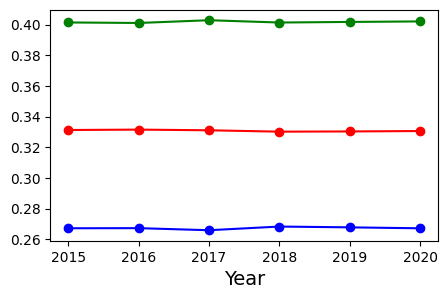

In [14]:
phis = [phi_ut_2015, phi_ut_2016, phi_ut_2017, phi_ut_2018, phi_ut_2019, phi_ut_2020]
stat_years = [2015, 2016, 2017, 2018, 2019, 2020]
frac_low = []
frac_mid = []
frac_high = []

for sp in range(ns):
    for i, phi in enumerate(phis):
        year = stat_years[i]
        # print(year, sp+1, np.nanmean(phi[sp]).round(3))
        if sp == 0:
            frac_low.append(np.nanmean(phi[sp]))
        elif sp == 1:
            frac_mid.append(np.nanmean(phi[sp]))
        elif sp == 2:
            frac_high.append(np.nanmean(phi[sp]))

mean_low = np.mean(frac_low)
mean_mid = np.mean(frac_mid)
mean_high = np.mean(frac_high)
print(f"Mean low income fraction: {mean_low:.3f}")
print(f"Mean middle income fraction: {mean_mid:.3f}")
print(f"Mean high income fraction: {mean_high:.3f}")

print(np.sum(mean_low + mean_mid + mean_high))

plt.figure(figsize=(5,3
                    ))
plt.plot(stat_years, frac_low, marker='o', label='Low income', color=species_colors[0])
plt.plot(stat_years, frac_mid, marker='o', label='Middle income', color=species_colors[1])
plt.plot(stat_years, frac_high, marker='o', label='High income', color  =species_colors[2])
plt.xlabel('Year', fontsize=ax_size)

In [84]:
leeg = []
for year in stat_years:
    data = eval(f"ut_gdf_reduced_{year}")
    leeg.append(np.mean(data["percentage_leeg"]))

mean_leeg = np.mean(leeg)
print(mean_leeg)
    

0.08118685571803241


In [15]:
dissim = []

for i, phi in enumerate(mirror):
    # phi_nonnan = np.where(np.isnan(phi), 0, phi)

    dissim.append(fhd.dissimilarity(phi))
    print(f"Year {stat_years[i]} dissimilarity: {dissim[-1]:.3f}")
print(f"Average dissimilarity: {np.mean(dissim):.3f}")

Year 2015 dissimilarity: 1.802
Year 2016 dissimilarity: 1.802
Year 2017 dissimilarity: 1.801
Year 2018 dissimilarity: 1.799
Year 2019 dissimilarity: 1.798
Year 2020 dissimilarity: 1.795
Average dissimilarity: 1.800


# Inference

## Build A


In [16]:
As = defaultdict(dict)
scales = defaultdict(dict)


for i, phi in enumerate(mirror[:-1]):
    for a in range(ns):
        if i==0:
            A, scale = fhd.build_A(phi, a, dx, dy, include_nu=True, include_Gamma=True, include_H=False)
            scale = np.append(scale, 0.0)
        else:
            A, scale = fhd.build_A(phi, a, dx, dy, include_nu=True, include_Gamma=True, include_H=True, H=H_prices[i-1])
        As[start_years[i]][a] = A
        scales[start_years[i]][a] = scale

# M1 Linear utility

## Thetas

In [19]:
Deltas = [1, 2, 3, 4, 5]
# Thetas_M1_y1 = np.zeros((n_data, 3, 12))
Thetas_M1 = defaultdict(dict)

for D_t in Deltas:
    for i in range(6-D_t):
        Thetas = fhd.compute_thetas(
        [As[start_years[i]][a] for a in range(ns)],  
        mirror[i],
        mirror[i+D_t],
        masks[i],   # Mask from earliest year
        dx, dy,
        ns,
        delta_t = D_t,
        include_nu = False,
        include_Gamma= True,
    )
        Thetas_M1[D_t][start_years[i]] = Thetas

In [20]:
thetas_all = {
    1: np.array([Thetas_M1[1][year] for year in start_years]),
    2: np.array([Thetas_M1[2][year] for year in start_years[:-1]]),
    3: np.array([Thetas_M1[3][year] for year in start_years[:-2]]),
    4: np.array([Thetas_M1[4][year] for year in start_years[:-3]]),
    5: np.array([Thetas_M1[5][year] for year in start_years[:-4]]),
}

ns = 3
n_params = 12

grouped_M1 = {
    species: {
        param: np.concatenate([
            theta[:, species, param] / timestep
            for timestep, theta in thetas_all.items()
        ])
        for param in range(n_params)
    }
    for species in range(ns)
}

## Parameter distribution

C:\Users\rmosk\AppData\Local\Temp\ipykernel_30240\4037910676.py:137: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


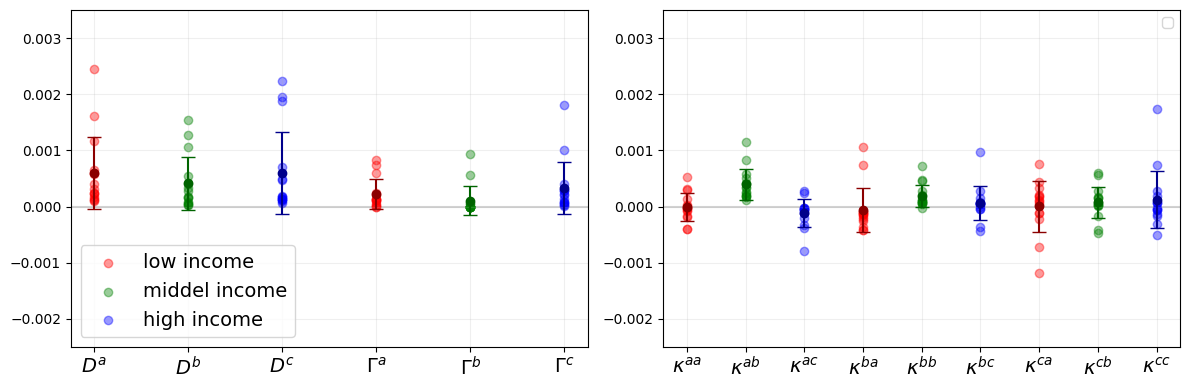

In [49]:
fig = plt.figure(figsize=(12,4))

# 1 rows, 2 columns
gs = fig.add_gridspec(1, 2)

# Top row
ax1 = fig.add_subplot(gs[0, 0])   # top-left
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)   # top-right

# ============================================================
# TOP SUBPLOT : D, kappa, gamma
# ============================================================

top_ax = ax1
top_ax.axhline(0, color='lightgray', zorder=0)

# ---- Labels on x-axis ----
top_labels = [
    r'$D^a$', r'$D^b$', r'$D^c$',
    r'$\Gamma^a$', r'$\Gamma^b$', r'$\Gamma^c$',
]

xpos_top = np.arange(len(top_labels))

# ---- Diffusion coefficients D ----
for i in range(ns):

    params = grouped_M1[i][0]

    mean = np.mean(params)
    std = np.std(params)

    x = np.full(len(params), xpos_top[i])

    top_ax.scatter(
        x,
        params,
        marker='o',
        alpha=0.4,
        color=species_colors[i],
        label=species[i]
    )

    top_ax.errorbar(
        xpos_top[i],
        mean,
        yerr=std,
        fmt='o',
        color=bar_colors[i],
        capsize=5
    )

for i in range(ns):

    params = grouped_M1[i][10]

    mean = np.mean(params)
    std = np.std(params)

    x = np.full(len(params), xpos_top[i+3])

    top_ax.scatter(
        x,
        params,
        marker='o',
        alpha=0.4,
        color=species_colors[i]
    )

    top_ax.errorbar(
        xpos_top[i+3],
        mean,
        yerr=std,
        fmt='o',
        color=bar_colors[i],
        capsize=5
    )

# ax1.set_ylim(-0.0002, 0.002)

ax1.set_xticks(xpos_top)
ax1.set_xticklabels(top_labels, fontsize=ax_size)
# ax[0].set_title(r"$D$ and $\Gamma$ parameters", size=title_size)
ax1.legend(fontsize=ax_size)

# ---- Kappa coefficients ----
# grouped_M3[sp][i+1]

top_ax = ax2
top_ax.axhline(0, color='lightgray', zorder=0)

kappa_labels = [
    r'$\kappa^{aa}$', r'$\kappa^{ab}$', r'$\kappa^{ac}$',
    r'$\kappa^{ba}$', r'$\kappa^{bb}$', r'$\kappa^{bc}$',
    r'$\kappa^{ca}$', r'$\kappa^{cb}$', r'$\kappa^{cc}$'
]

xpos_kappa = np.arange(len(kappa_labels))

inx = 0
for sp in range(ns):

    for i in range(ns):

        params = grouped_M1[sp][i+1]

        mean = np.mean(params)
        std = np.std(params)

        x = np.full(len(params), xpos_kappa[inx])

        top_ax.scatter(
            x,
            params,
            marker='o',
            alpha=0.4,
            color=species_colors[i]
        )

        top_ax.errorbar(
            xpos_kappa[inx],
            mean,
            yerr=std,
            fmt='o',
            color=bar_colors[i],
            capsize=5
        )
        inx += 1

# ax2.set_ylim(-2e-6, 5e-6)
ax2.set_ylim(-0.0025, 0.0035)

ax2.set_xticks(xpos_kappa)
ax2.set_xticklabels(kappa_labels, fontsize=ax_size)
# ax[1].set_title("κ parameters", size=title_size)
# ax1.set_ylim(-0.0002, 0.0002)
ax2.legend()

ax = [ax1, ax2]

for a in ax:
    a.grid(alpha=0.2)

# ax[1].set_ylabel("Parameter value", size=ax_size)

plt.tight_layout()
plt.show()

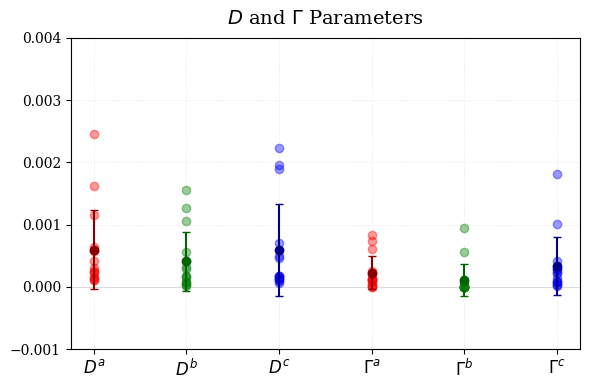

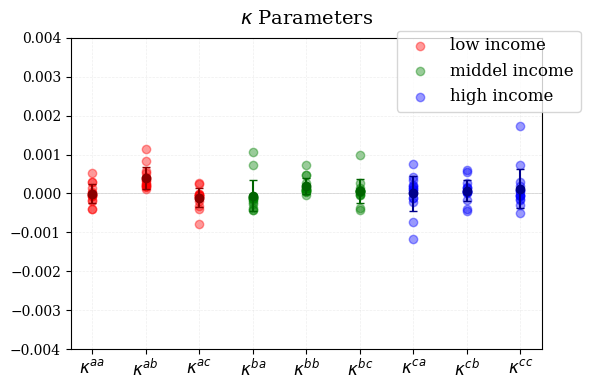

In [81]:
# Set global font properties (same as final plot)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# ============================================================
# FIRST FIGURE: D and Gamma
# ============================================================
fig1, ax1 = plt.subplots(figsize=(6, 4))

ax1.axhline(0, color='lightgray', zorder=0, linewidth=0.5)

top_labels = [
    r'$D^a$', r'$D^b$', r'$D^c$',
    r'$\Gamma^a$', r'$\Gamma^b$', r'$\Gamma^c$'
]
xpos_top = np.arange(len(top_labels))

# Plot D parameters
for i in range(ns):
    params = grouped_M1[i][0]
    mean = np.mean(params)
    std = np.std(params)
    x = np.full(len(params), xpos_top[i])
    ax1.scatter(
        x,
        params,
        marker='o',
        alpha=0.4,
        color=species_colors[i],
        label=species[i]
    )
    ax1.errorbar(
        xpos_top[i],
        mean,
        yerr=std,
        fmt='o',
        color=bar_colors[i],
        capsize=3
    )

# Plot Gamma parameters
for i in range(ns):
    params = grouped_M1[i][10]
    mean = np.mean(params)
    std = np.std(params)
    x = np.full(len(params), xpos_top[i+3])
    ax1.scatter(
        x,
        params,
        marker='o',
        alpha=0.4,
        color=species_colors[i]
    )
    ax1.errorbar(
        xpos_top[i+3],
        mean,
        yerr=std,
        fmt='o',
        color=bar_colors[i],
        capsize=3
    )

ax1.set_xticks(xpos_top)
ax1.set_xticklabels(top_labels, fontsize=12)
# ax1.set_ylabel("Parameter Value", fontsize=12)
# ax1.legend(loc='upper right', bbox_to_anchor=(1.1, 1.05), fontsize=12)
ax1.set_title(r"$D$ and $\Gamma$ Parameters", fontsize=14, pad=10)
ax1.grid(alpha=0.2, linestyle='--', linewidth=0.5)
ax1.set_ylim(-0.001, 0.004)

plt.tight_layout()
plt.show()

# ============================================================
# SECOND FIGURE: Kappa
# ============================================================
fig2, ax2 = plt.subplots(figsize=(6, 4))

ax2.axhline(0, color='lightgray', zorder=0, linewidth=0.5)

kappa_labels = [
    r'$\kappa^{aa}$', r'$\kappa^{ab}$', r'$\kappa^{ac}$',
    r'$\kappa^{ba}$', r'$\kappa^{bb}$', r'$\kappa^{bc}$',
    r'$\kappa^{ca}$', r'$\kappa^{cb}$', r'$\kappa^{cc}$'
]
xpos_kappa = np.arange(len(kappa_labels))

inx = 0
for sp in range(ns):
    for i in range(ns):
        params = grouped_M1[sp][i+1]
        mean = np.mean(params)
        std = np.std(params)
        x = np.full(len(params), xpos_kappa[inx])
        ax2.scatter(
            x,
            params,
            marker='o',
            alpha=0.4,
            color=species_colors[sp],
            label=species[sp] if i == 0 else ""
        )
        ax2.errorbar(
            xpos_kappa[inx],
            mean,
            yerr=std,
            fmt='o',
            color=bar_colors[sp],
            capsize=3
        )
        inx += 1

ax2.set_xticks(xpos_kappa)
ax2.set_xticklabels(kappa_labels, fontsize=12)
ax2.set_title(r"$\kappa$ Parameters", fontsize=14, pad=10)
ax2.grid(alpha=0.2, linestyle='--', linewidth=0.5)
ax2.set_ylim(-0.004, 0.004)
ax2.legend(loc='upper right', bbox_to_anchor=(1.1, 1.05), fontsize=12)

plt.tight_layout()
plt.show()

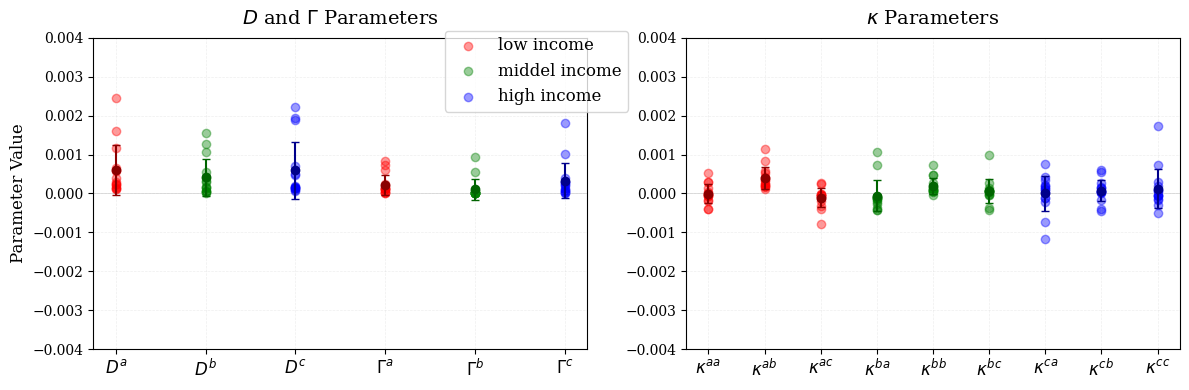

In [64]:
# Set global font properties (same as final plot)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Create figure with adjusted size
fig = plt.figure(figsize=(12, 4))

# 1 row, 2 columns
gs = fig.add_gridspec(1, 2)

# Top row
ax1 = fig.add_subplot(gs[0, 0])  # left
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)  # right

# ============================================================
# LEFT SUBPLOT: D and Gamma
# ============================================================
top_ax = ax1
top_ax.axhline(0, color='lightgray', zorder=0, linewidth=0.5)

top_labels = [
    r'$D^a$', r'$D^b$', r'$D^c$',
    r'$\Gamma^a$', r'$\Gamma^b$', r'$\Gamma^c$'
]
xpos_top = np.arange(len(top_labels))

# Plot D parameters
for i in range(ns):
    params = grouped_M1[i][0]
    mean = np.mean(params)
    std = np.std(params)
    x = np.full(len(params), xpos_top[i])
    top_ax.scatter(
        x,
        params,
        marker='o',
        alpha=0.4,
        color=species_colors[i],
        label=species[i]
    )
    top_ax.errorbar(
        xpos_top[i],
        mean,
        yerr=std,
        fmt='o',
        color=bar_colors[i],
        capsize=3
    )

# Plot Gamma parameters
for i in range(ns):
    params = grouped_M1[i][10]
    mean = np.mean(params)
    std = np.std(params)
    x = np.full(len(params), xpos_top[i+3])
    top_ax.scatter(
        x,
        params,
        marker='o',
        alpha=0.4,
        color=species_colors[i]
    )
    top_ax.errorbar(
        xpos_top[i+3],
        mean,
        yerr=std,
        fmt='o',
        color=bar_colors[i],
        capsize=3
    )

ax1.set_xticks(xpos_top)
ax1.set_xticklabels(top_labels, fontsize=12)
ax1.set_ylabel("Parameter Value", fontsize=12)
ax1.legend(loc='upper right', bbox_to_anchor=(1.1, 1.05), fontsize=12)
ax1.set_title(r"$D$ and $\Gamma$ Parameters", fontsize=14, pad=10)

# ============================================================
# RIGHT SUBPLOT: Kappa
# ============================================================
top_ax = ax2
top_ax.axhline(0, color='lightgray', zorder=0, linewidth=0.5)

kappa_labels = [
    r'$\kappa^{aa}$', r'$\kappa^{ab}$', r'$\kappa^{ac}$',
    r'$\kappa^{ba}$', r'$\kappa^{bb}$', r'$\kappa^{bc}$',
    r'$\kappa^{ca}$', r'$\kappa^{cb}$', r'$\kappa^{cc}$'
]
xpos_kappa = np.arange(len(kappa_labels))

inx = 0
for sp in range(ns):
    for i in range(ns):
        params = grouped_M1[sp][i+1]
        mean = np.mean(params)
        std = np.std(params)
        x = np.full(len(params), xpos_kappa[inx])
        top_ax.scatter(
            x,
            params,
            marker='o',
            alpha=0.4,
            color=species_colors[sp]
        )
        top_ax.errorbar(
            xpos_kappa[inx],
            mean,
            yerr=std,
            fmt='o',
            color=bar_colors[sp],
            capsize=3
        )
        inx += 1

ax2.set_xticks(xpos_kappa)
ax2.set_xticklabels(kappa_labels, fontsize=12)
ax2.set_title(r"$\kappa$ Parameters", fontsize=14, pad=10)

# ============================================================
# Shared formatting
# ============================================================
for a in [ax1, ax2]:
    a.grid(alpha=0.2, linestyle='--', linewidth=0.5)
    a.set_ylim(-0.004, 0.004)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2)
plt.show()

## Performance

In [ ]:
N = (n-1, n-1)
L = (50,50)
Lx, Ly = L
sim_2d_fitted = fhd.fhd_2d_3species(L,N, bc= 'Neumann', fft=False)

noise = 0
frames = 1

ns = sim_2d_fitted.nspecies

Deltats = [1,2,3,4,5]

phi_M1 = []


for i, Dt in enumerate(Deltats):
    for yr in range(6-Dt):
        scaled_theta = [Thetas_M1[Dt][start_years[yr]][a] * scales[start_years[yr]][a] for a in range(ns)]
        D_fit, kappa_fit, nu_fit, Gamma_fit = fhd.unpack_theta(scaled_theta, ns, include_nu=False, include_Gamma=True, include_H=False)

        Gamma_fit_m = np.diag(Gamma_fit)

        param_fitted = {
            'D': D_fit / Dt,
            'kappa': kappa_fit / Dt,
            'Gamma': Gamma_fit_m / Dt,
        }

        # params_M1[i][yr].append(param_fitted)
        time_step = Dt 
        dt = 1
        nsteps = int(time_step / dt)

        st = time.time()
        phi_run = sim_2d_fitted.run(mirror[yr], param_fitted, nsteps, dt, noise, frames, model = "Vitelli", verbatum = False)
        et = time.time()
        # print(f"Simulation ran in t = {et-st:.6f} seconds")

        phi_masked = phi_run.copy()
        phi_masked[:,-1][masks[yr+Dt]] = 0.0
        # print(len(phi_M1), Dt, yr)

        phi_M1.append(phi_masked[:,-1])


In [23]:
n_years = 6
mse_M1_y1t = np.zeros((n_years-1,ns))
mse_M1_y2t = np.zeros((n_years-2,ns))
mse_M1_y3t = np.zeros((n_years-3,ns))
mse_M1_y4t = np.zeros((n_years-4,ns))
mse_M1_y5t = np.zeros((n_years-5,ns))

for i, year in enumerate(range(2016, 2021)):
    data_year = eval(f"data_{year}")
    mse_M1_y1t[i] =  [np.mean((phi_M1[i][sp,:] - data_year[sp,:])**2) / bases[i][sp] for sp in range(ns)]

for i, year in enumerate(range(2017, 2021)):
    data_year = eval(f"data_{year}")
    mse_M1_y2t[i] = [np.mean((phi_M1[i+5][sp,:] - data_year[sp,:])**2) / bases_2y[i][sp] for sp in range(ns)]
    
for i, year in enumerate(range(2018, 2021)):
    data_year = eval(f"data_{year}")
    mse_M1_y3t[i] = [np.mean((phi_M1[i+9][sp,:] - data_year[sp,:])**2) / bases_3y[i][sp] for sp in range(ns)]

for i, year in enumerate(range(2019, 2021)):
    data_year = eval(f"data_{year}")
    mse_M1_y4t[i] = [np.mean((phi_M1[i+12][sp,:] - data_year[sp,:])**2) / bases_4y[i][sp] for sp in range(ns)]

for i, year in enumerate(range(2020, 2021)):
    data_year = eval(f"data_{year}")
    mse_M1_y5t[i] = [np.mean((phi_M1[i+14][sp,:] - data_year[sp,:])**2) / bases_5y[i][sp] for sp in range(ns)]


# Model 2 Quadratic utility

In [24]:
Deltas = [1, 2, 3, 4, 5]
Thetas_M2 = defaultdict(dict)

for D_t in Deltas:
    for i in range(6-D_t):
        Thetas = fhd.compute_thetas(
        [As[start_years[i]][a] for a in range(ns)],  
        mirror[i],
        mirror[i+D_t],
        masks[i],   # Mask from earliest year
        dx, dy,
        ns,
        delta_t = D_t,
        include_nu = True,
        include_Gamma= True,
    )
        Thetas_M2[D_t][start_years[i]] = Thetas

## Parameter distribution

In [26]:
thetas_all = {
    1: np.array([Thetas_M2[1][year] for year in start_years]),
    2: np.array([Thetas_M2[2][year] for year in start_years[:-1]]),
    3: np.array([Thetas_M2[3][year] for year in start_years[:-2]]),
    4: np.array([Thetas_M2[4][year] for year in start_years[:-3]]),
    5: np.array([Thetas_M2[5][year] for year in start_years[:-4]]),
}

ns = 3
n_params = 12

grouped_M2 = {
    species: {
        param: np.concatenate([
            theta[:, species, param] / timestep
            for timestep, theta in thetas_all.items()
        ])
        for param in range(n_params)
    }
    for species in range(ns)
}

C:\Users\rmosk\AppData\Local\Temp\ipykernel_30240\2740209143.py:152: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(fontsize=ax_size)


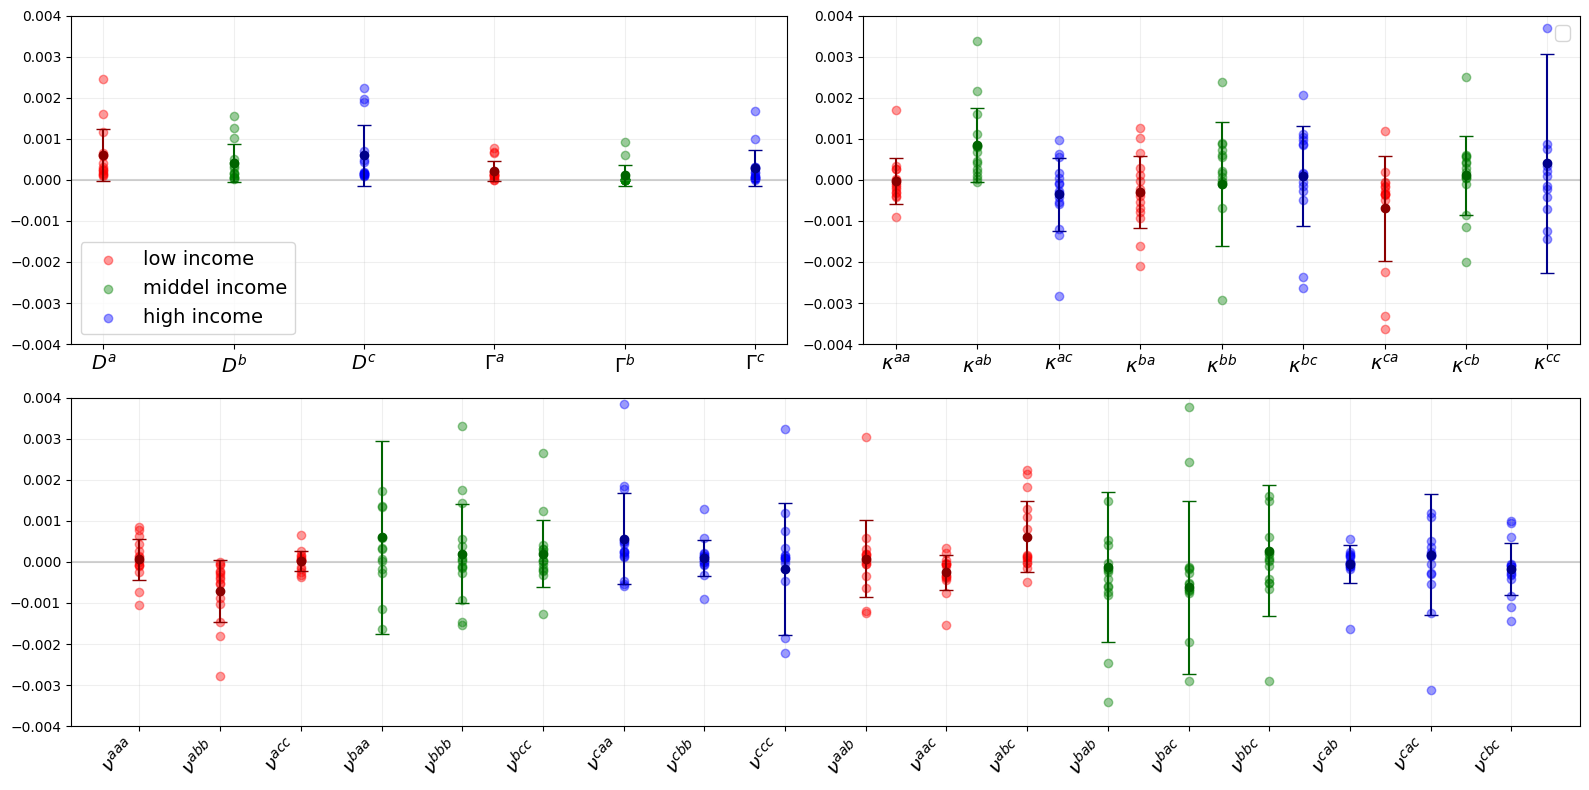

In [52]:
# One figure with two stacked subplots:
# Top: D, kappa, gamma parameters
# Bottom: all nu parameters
# Both share the same y-axis

fig = plt.figure(figsize=(16,8))

# 2 rows, 2 columns
gs = fig.add_gridspec(2, 2)

# Top row
ax1 = fig.add_subplot(gs[0, 0])   # top-left
ax2 = fig.add_subplot(gs[0, 1], sharey = ax1)   # top-right

# Bottom row spans BOTH columns
ax3 = fig.add_subplot(gs[1, :], sharey = ax2)

ax = [ax1, ax2, ax3]

# fig.suptitle(
#     "Parameter distribution for quadratic utility model",
#     size=title_size + 2
# )

# ============================================================
# TOP SUBPLOT : D, kappa, gamma
# ============================================================

top_ax = ax[0]
top_ax.axhline(0, color='lightgray', zorder=0)

# ---- Labels on x-axis ----
top_labels = [
    r'$D^a$', r'$D^b$', r'$D^c$',
    r'$\Gamma^a$', r'$\Gamma^b$', r'$\Gamma^c$'
]

xpos_top = np.arange(len(top_labels))

# ---- Diffusion coefficients D ----
for i in range(ns):

    params = grouped_M2[i][0]

    mean = np.mean(params)
    std = np.std(params)

    x = np.full(len(params), xpos_top[i])

    top_ax.scatter(
        x,
        params,
        marker='o',
        alpha=0.4,
        color=species_colors[i],
        label=species[i]
    )

    top_ax.errorbar(
        xpos_top[i],
        mean,
        yerr=std,
        fmt='o',
        color=bar_colors[i],
        capsize=5
    )

# ---- Gamma coefficients ----
for i in range(ns):

    params = grouped_M2[i][10]

    mean = np.mean(params)
    std = np.std(params)

    x_index = 3 + i
    x = np.full(len(params), xpos_top[x_index])

    top_ax.scatter(
        x,
        params,
        marker='o',
        alpha=0.4,
        color=species_colors[i]
    )

    top_ax.errorbar(
        xpos_top[x_index],
        mean,
        yerr=std,
        fmt='o',
        color=bar_colors[i],
        capsize=5
    )

ax[0].set_xticks(xpos_top)
ax[0].set_xticklabels(top_labels, fontsize=ax_size)
# ax[0].set_title(r"$D$ and $\Gamma$ parameters", size=title_size)
ax[0].legend(fontsize=ax_size)

# ax[0].set_ylim(-0.0002, 0.004)
# ax[0].set_ylim(-0.002, 0.003)

# ---- Kappa coefficients ----
# grouped_M3[sp][i+1]

top_ax = ax[1]
top_ax.axhline(0, color='lightgray', zorder=0)

kappa_labels = [
    r'$\kappa^{aa}$', r'$\kappa^{ab}$', r'$\kappa^{ac}$',
    r'$\kappa^{ba}$', r'$\kappa^{bb}$', r'$\kappa^{bc}$',
    r'$\kappa^{ca}$', r'$\kappa^{cb}$', r'$\kappa^{cc}$'
]

xpos_kappa = np.arange(len(kappa_labels))

inx = 0
for sp in range(ns):

    for i in range(ns):

        params = grouped_M2[sp][i+1]

        mean = np.mean(params)
        std = np.std(params)

        x = np.full(len(params), xpos_kappa[inx])

        top_ax.scatter(
            x,
            params,
            marker='o',
            alpha=0.4,
            color=species_colors[i]
        )

        top_ax.errorbar(
            xpos_kappa[inx],
            mean,
            yerr=std,
            fmt='o',
            color=bar_colors[i],
            capsize=5
        )
        inx += 1


ax[1].set_xticks(xpos_kappa)
ax[1].set_xticklabels(kappa_labels, fontsize=ax_size)
# ax[1].set_title("κ parameters", size=title_size)
ax[1].legend(fontsize=ax_size)


# ============================================================
# BOTTOM SUBPLOT : all nu parameters
# ============================================================

bottom_ax = ax[2]
bottom_ax.axhline(0, color='lightgray', zorder=0)

nu_labels = [
    r'$\nu^{aaa}$', r'$\nu^{abb}$', r'$\nu^{acc}$',
    r'$\nu^{baa}$', r'$\nu^{bbb}$', r'$\nu^{bcc}$',
    r'$\nu^{caa}$', r'$\nu^{cbb}$', r'$\nu^{ccc}$',
    r'$\nu^{aab}$', r'$\nu^{aac}$', r'$\nu^{abc}$',
    r'$\nu^{bab}$', r'$\nu^{bac}$', r'$\nu^{bbc}$',
    r'$\nu^{cab}$', r'$\nu^{cac}$', r'$\nu^{cbc}$'
]

xpos_bottom = np.arange(len(nu_labels))

# First 9 nu terms
nu_index = 0

for sp in range(ns):

    for i in range(ns):

        params = grouped_M2[sp][i+4]

        mean = np.mean(params)
        std = np.std(params)

        x = np.full(len(params), xpos_bottom[nu_index])

        bottom_ax.scatter(
            x,
            params,
            marker='o',
            alpha=0.4,
            color=species_colors[sp]
        )

        bottom_ax.errorbar(
            xpos_bottom[nu_index],
            mean,
            yerr=std,
            fmt='o',
            color=bar_colors[sp],
            capsize=5
        )

        nu_index += 1

# Second 9 nu terms
nu_index = 9

for sp in range(ns):

    for i in range(ns):

        params = grouped_M2[sp][i+7]

        mean = np.mean(params)
        std = np.std(params)

        x = np.full(len(params), xpos_bottom[nu_index])

        bottom_ax.scatter(
            x,
            params,
            marker='o',
            alpha=0.4,
            color=species_colors[sp]
        )

        bottom_ax.errorbar(
            xpos_bottom[nu_index],
            mean,
            yerr=std,
            fmt='o',
            color=bar_colors[sp],
            capsize=5
        )

        nu_index += 1

bottom_ax.set_xticks(xpos_bottom)
bottom_ax.set_xticklabels(
    nu_labels,
    rotation=45,
    ha='right',
    fontsize=ax_size
)

# bottom_ax.set_ylim(-2e-6, 5e-6)
ax2.set_ylim(-0.004, 0.004)
# ax1.set_ylim(-0.0025, 0.0035)

# bottom_ax.set_title(r'$\nu$ coefficients', size=title_size)

# ============================================================
# Shared formatting
# ============================================================

for a in ax:
    a.grid(alpha=0.2)

# ax[1].set_ylabel("Parameter value", size=ax_size)

plt.tight_layout()
plt.show()

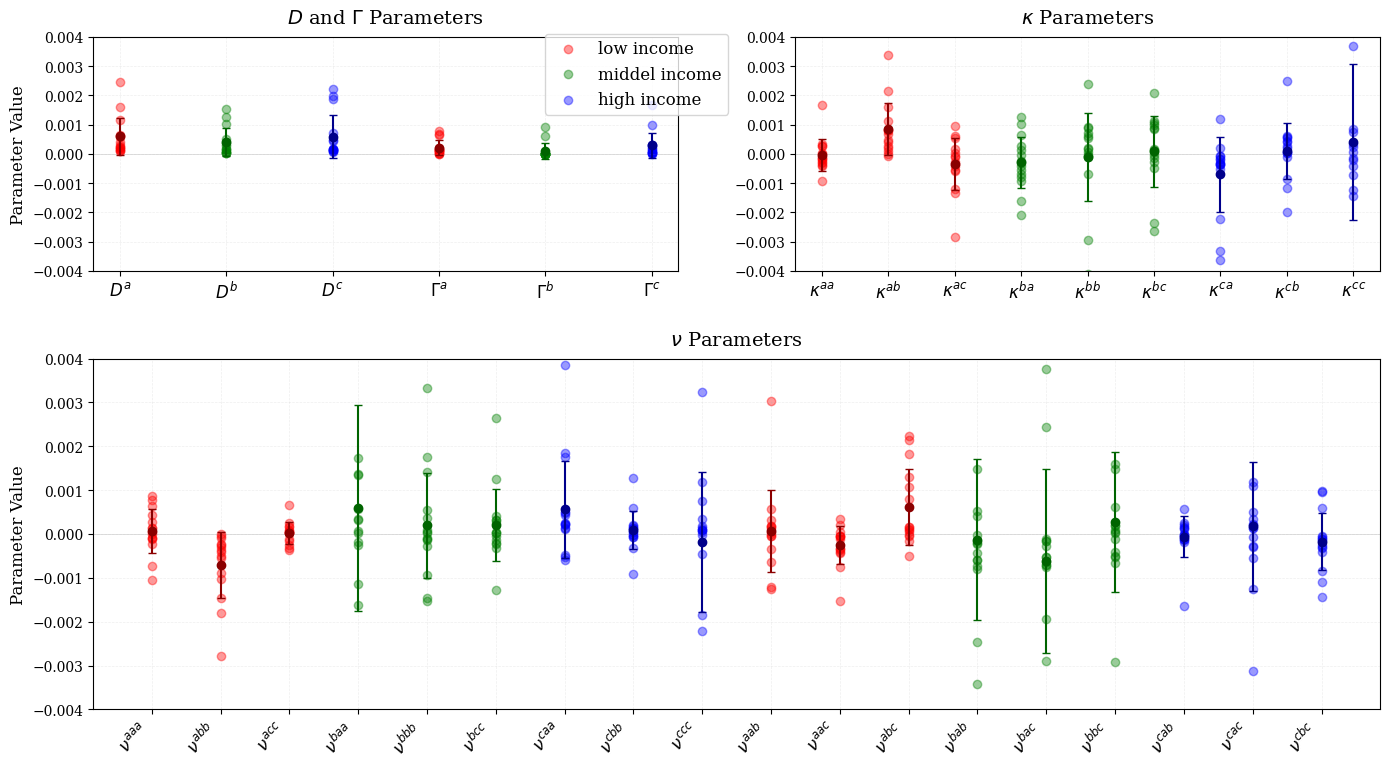

In [ ]:
# Set global font properties
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

ns = len(species)

# Create figure with adjusted size
fig = plt.figure(figsize=(14, 8))

# 2 rows, 2 columns
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.5])

# Top row
ax1 = fig.add_subplot(gs[0, 0])  # top-left
ax2 = fig.add_subplot(gs[0, 1], sharey=ax1)  # top-right

# Bottom row spans both columns
ax3 = fig.add_subplot(gs[1, :], sharey=ax2)

ax = [ax1, ax2, ax3]

# ============================================================
# TOP SUBPLOT: D, kappa, gamma
# ============================================================

# --- D and Gamma (left) ---
top_ax = ax[0]
top_ax.axhline(0, color='lightgray', zorder=0, linewidth=0.5)

top_labels = [
    r'$D^a$', r'$D^b$', r'$D^c$',
    r'$\Gamma^a$', r'$\Gamma^b$', r'$\Gamma^c$'
]
xpos_top = np.arange(len(top_labels))

# Plot D parameters
for i in range(ns):
    params = grouped_M2[i][0]
    mean = np.mean(params)
    std = np.std(params)
    x = np.full(len(params), xpos_top[i])
    top_ax.scatter(x, params, marker='o', alpha=0.4, color=species_colors[i], label=species[i])
    top_ax.errorbar(xpos_top[i], mean, yerr=std, fmt='o', color=bar_colors[i], capsize=3)

# Plot Gamma parameters
for i in range(ns):
    params = grouped_M2[i][10]
    mean = np.mean(params)
    std = np.std(params)
    x_index = 3 + i
    x = np.full(len(params), xpos_top[x_index])
    top_ax.scatter(x, params, marker='o', alpha=0.4, color=species_colors[i])
    top_ax.errorbar(xpos_top[x_index], mean, yerr=std, fmt='o', color=bar_colors[i], capsize=3)

ax[0].set_xticks(xpos_top)
ax[0].set_xticklabels(top_labels, fontsize=12)
ax[0].set_ylabel("Parameter Value", fontsize=12)
ax[0].legend(loc='upper right', bbox_to_anchor=(1.1, 1.05), fontsize=12)
ax[0].set_title(r"$D$ and $\Gamma$ Parameters", fontsize=14, pad=10)

# --- Kappa (right) ---
top_ax = ax[1]
top_ax.axhline(0, color='lightgray', zorder=0, linewidth=0.5)

kappa_labels = [
    r'$\kappa^{aa}$', r'$\kappa^{ab}$', r'$\kappa^{ac}$',
    r'$\kappa^{ba}$', r'$\kappa^{bb}$', r'$\kappa^{bc}$',
    r'$\kappa^{ca}$', r'$\kappa^{cb}$', r'$\kappa^{cc}$'
]
xpos_kappa = np.arange(len(kappa_labels))

inx = 0
for sp in range(ns):
    for i in range(ns):
        params = grouped_M2[sp][i+1]
        mean = np.mean(params)
        std = np.std(params)
        x = np.full(len(params), xpos_kappa[inx])
        top_ax.scatter(x, params, marker='o', alpha=0.4, color=species_colors[sp])
        top_ax.errorbar(xpos_kappa[inx], mean, yerr=std, fmt='o', color=bar_colors[sp], capsize=3)
        inx += 1

ax[1].set_xticks(xpos_kappa)
ax[1].set_xticklabels(kappa_labels, fontsize=12)
ax[1].set_title(r"$\kappa$ Parameters", fontsize=14, pad=10)

# ============================================================
# BOTTOM SUBPLOT: all nu parameters
# ============================================================

bottom_ax = ax[2]
bottom_ax.axhline(0, color='lightgray', zorder=0, linewidth=0.5)

nu_labels = [
    r'$\nu^{aaa}$', r'$\nu^{abb}$', r'$\nu^{acc}$',
    r'$\nu^{baa}$', r'$\nu^{bbb}$', r'$\nu^{bcc}$',
    r'$\nu^{caa}$', r'$\nu^{cbb}$', r'$\nu^{ccc}$',
    r'$\nu^{aab}$', r'$\nu^{aac}$', r'$\nu^{abc}$',
    r'$\nu^{bab}$', r'$\nu^{bac}$', r'$\nu^{bbc}$',
    r'$\nu^{cab}$', r'$\nu^{cac}$', r'$\nu^{cbc}$'
]
xpos_bottom = np.arange(len(nu_labels))

# Plot all nu parameters
nu_index = 0
for sp in range(ns):
    for i in range(ns):
        params = grouped_M2[sp][i+4]
        mean = np.mean(params)
        std = np.std(params)
        x = np.full(len(params), xpos_bottom[nu_index])
        bottom_ax.scatter(x, params, marker='o', alpha=0.4, color=species_colors[sp])
        bottom_ax.errorbar(xpos_bottom[nu_index], mean, yerr=std, fmt='o', color=bar_colors[sp], capsize=3)
        nu_index += 1

nu_index = 9
for sp in range(ns):
    for i in range(ns):
        params = grouped_M2[sp][i+7]
        mean = np.mean(params)
        std = np.std(params)
        x = np.full(len(params), xpos_bottom[nu_index])
        bottom_ax.scatter(x, params, marker='o', alpha=0.4, color=species_colors[sp])
        bottom_ax.errorbar(xpos_bottom[nu_index], mean, yerr=std, fmt='o', color=bar_colors[sp], capsize=3)
        nu_index += 1

bottom_ax.set_xticks(xpos_bottom)
bottom_ax.set_xticklabels(nu_labels, rotation=45, ha='right', fontsize=12)
bottom_ax.set_ylabel("Parameter Value", fontsize=12)
bottom_ax.set_title(r"$\nu$ Parameters", fontsize=14, pad=10)

# ============================================================
# Shared formatting
# ============================================================

for a in ax:
    a.grid(alpha=0.2, linestyle='--', linewidth=0.5)
    a.set_ylim(-0.004, 0.004)

plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.3, wspace=0.2)
plt.show()

## performance

In [ ]:
N = (n-1, n-1)
L = (50,50)
Lx, Ly = L
sim_2d_fitted = fhd.fhd_2d_3species(L,N, bc= 'Neumann', fft=False)

noise = 0
frames = 1

ns = sim_2d_fitted.nspecies

Deltats = [1,2,3,4,5]

phi_M2 = []


for i, Dt in enumerate(Deltats):
    for yr in range(6-Dt):
        scaled_theta = [Thetas_M2[Dt][start_years[yr]][a] * scales[start_years[yr]][a] for a in range(ns)]
        D_fit, kappa_fit, nu_fit, Gamma_fit = fhd.unpack_theta(scaled_theta, ns, include_nu=False, include_Gamma=True, include_H=False)

        Gamma_fit_m = np.diag(Gamma_fit)

        param_fitted = {
            'D': D_fit / Dt,
            'kappa': kappa_fit / Dt,
            'Gamma': Gamma_fit_m / Dt,
        }

        
        time_step = Dt 
        dt = 1
        nsteps = int(time_step / dt)

        st = time.time()
        phi_run = sim_2d_fitted.run(mirror[yr], param_fitted, nsteps, dt, noise, frames, model = "Vitelli", verbatum = False)
        et = time.time()
        # print(f"Simulation ran in t = {et-st:.6f} seconds")

        phi_masked = phi_run.copy()
        phi_masked[:,-1][masks[yr+Dt]] = 0.0
        

        phi_M2.append(phi_masked[:,-1])


In [30]:
n_years = 6
mse_M2_y1t = np.zeros((n_years-1,ns))
mse_M2_y2t = np.zeros((n_years-2,ns))
mse_M2_y3t = np.zeros((n_years-3,ns))
mse_M2_y4t = np.zeros((n_years-4,ns))
mse_M2_y5t = np.zeros((n_years-5,ns))

for i, year in enumerate(range(2016, 2021)):
    data_year = eval(f"data_{year}")
    mse_M2_y1t[i] =  [np.mean((phi_M2[i][sp,:] - data_year[sp,:])**2) / bases[i][sp] for sp in range(ns)]

for i, year in enumerate(range(2017, 2021)):
    data_year = eval(f"data_{year}")
    mse_M2_y2t[i] = [np.mean((phi_M2[i+5][sp,:] - data_year[sp,:])**2) / bases_2y[i][sp] for sp in range(ns)]
    
for i, year in enumerate(range(2018, 2021)):
    data_year = eval(f"data_{year}")
    mse_M2_y3t[i] = [np.mean((phi_M2[i+9][sp,:] - data_year[sp,:])**2) / bases_3y[i][sp] for sp in range(ns)]

for i, year in enumerate(range(2019, 2021)):
    data_year = eval(f"data_{year}")
    mse_M2_y4t[i] = [np.mean((phi_M2[i+12][sp,:] - data_year[sp,:])**2) / bases_4y[i][sp] for sp in range(ns)]

for i, year in enumerate(range(2020, 2021)):
    data_year = eval(f"data_{year}")
    mse_M2_y5t[i] = [np.mean((phi_M2[i+14][sp,:] - data_year[sp,:])**2) / bases_5y[i][sp] for sp in range(ns)]


# Model H0 (only economic)

In [31]:
Deltas = [1, 2, 3, 4]
Thetas_MH0 = defaultdict(dict)

for D_t in Deltas:
    for i in range(5-D_t):
        Thetas, std = fhd.infer_eco(  
        mirror[i+1],
        mirror[i+D_t+1],
        masks[i+1],   # Mask from earliest year
        dx, dy,
        ns,
        delta_t = D_t,
        H = H_prices[i],
    )
        Thetas_MH0[D_t][start_years[i+1]] = Thetas

In [32]:
eco_start_years = start_years[1:]

thetas_all = {
    1: np.array([Thetas_MH0[1][year] for year in eco_start_years]),
    2: np.array([Thetas_MH0[2][year] for year in eco_start_years[:-1]]),
    3: np.array([Thetas_MH0[3][year] for year in eco_start_years[:-2]]),
    4: np.array([Thetas_MH0[4][year] for year in eco_start_years[:-3]]),
}

ns = 3
n_params = 2

grouped_MH0 = {
    species: {
        param: np.concatenate([
            theta[:, species, param] / timestep
            for timestep, theta in thetas_all.items()
        ])
        for param in range(n_params)
    }
    for species in range(ns)
}

## Parameter distribution

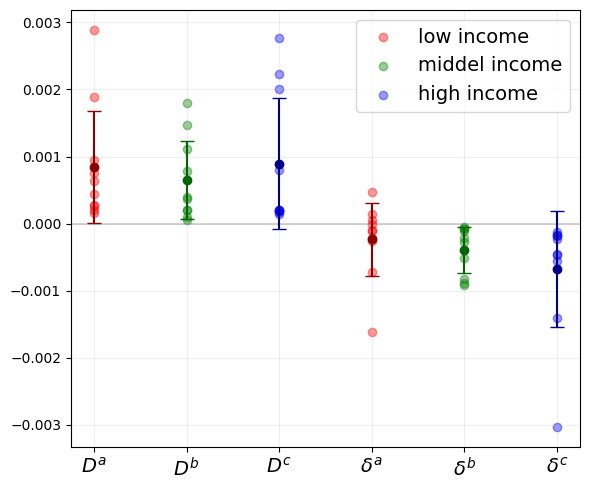

In [33]:
# Create a single subplot figure
fig, ax1 = plt.subplots(figsize=(6, 5))

# Plot for D and Gamma parameters
ax1.axhline(0, color='lightgray', zorder=0)

# Labels for D and Gamma
top_labels = [
    r'$D^a$', r'$D^b$', r'$D^c$',
    r'$\delta^a$', r'$\delta^b$', r'$\delta^c$',
]

xpos_top = np.arange(len(top_labels))

# Plot D parameters
for i in range(ns):
    params = grouped_MH0[i][0]
    mean = np.mean(params)
    std = np.std(params)
    x = np.full(len(params), xpos_top[i])

    ax1.scatter(
        x,
        params,
        marker='o',
        alpha=0.4,
        color=species_colors[i],
        label=species[i]
    )

    ax1.errorbar(
        xpos_top[i],
        mean,
        yerr=std,
        fmt='o',
        color=bar_colors[i],
        capsize=5
    )

# Plot Gamma parameters
for i in range(ns):
    params = grouped_MH0[i][1]
    mean = np.mean(params)
    std = np.std(params)
    x = np.full(len(params), xpos_top[i+3])

    ax1.scatter(
        x,
        params,
        marker='o',
        alpha=0.4,
        color=species_colors[i]
    )

    ax1.errorbar(
        xpos_top[i+3],
        mean,
        yerr=std,
        fmt='o',
        color=bar_colors[i],
        capsize=5
    )

# Set limits and labels
# ax1.set_ylim(-0.0002, 0.002)
ax1.set_xticks(xpos_top)
ax1.set_xticklabels(top_labels, fontsize=ax_size)
ax1.legend(fontsize=ax_size)
ax1.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Performance

In [34]:
N = (n-1, n-1)
L = (50,50)
Lx, Ly = L
sim_2d_fitted = fhd.fhd_2d_3species(L,N, bc= 'Neumann', fft=False)

noise = 0
frames = 1

ns = sim_2d_fitted.nspecies

Deltats = [1,2,3,4]

phi_MH0 = []
Dt  = 1
yr = 0

# print(scales[start_years[yr]][0][0])

# print(Thetas_MH0[Dt][eco_start_years[yr]][0][0] * scales[start_years[yr]][0])

for i, Dt in enumerate(Deltats):
    for yr in range(5-Dt):
        kappa_fit = np.zeros((ns, ns))
        nu_fit = np.zeros((ns, ns, ns))
        Gamma_fit = np.zeros((ns, ns))

        # scaled_theta = [Thetas_M1[Dt][start_years[yr]][a] * scales[start_years[yr]][a] for a in range(ns)]

        D_fit = [Thetas_MH0[Dt][eco_start_years[yr]][a][0] * scales[start_years[yr]][a][0] for a in range(ns)]
        delta_fit = [Thetas_MH0[Dt][eco_start_years[yr]][a][1] * scales[start_years[yr]][a][-1] for a in range(ns)]

        D_fit = np.array(D_fit)
        delta_fit = np.array(delta_fit)

        param_fitted = {
            'D': D_fit / Dt,
            'kappa': kappa_fit,
            'Gamma': Gamma_fit,
            'nu': nu_fit,
            'delta' : delta_fit / Dt
        }

        # params_M1[i][yr].append(param_fitted)
        time_step = Dt 
        dt = 1
        nsteps = int(time_step / dt)

        st = time.time()
        phi_run = sim_2d_fitted.run(mirror[yr+1], param_fitted, nsteps, dt, noise, frames, model = "Vitelli", H = H_prices[yr], verbatum = False)
        et = time.time()
        # print(f"Simulation ran in t = {et-st:.6f} seconds")

        phi_masked = phi_run.copy()
        phi_masked[:,-1][masks[yr+Dt+1]] = 0.0
        # print(len(phi_M1), Dt, yr)

        phi_MH0.append(phi_masked[:,-1])


In [35]:
n_years = 5
mse_MH0_y1t = np.zeros((n_years-1,ns))
mse_MH0_y2t = np.zeros((n_years-2,ns))
mse_MH0_y3t = np.zeros((n_years-3,ns))
mse_MH0_y4t = np.zeros((n_years-4,ns))

for i, year in enumerate(range(2017, 2021)):
    data_year = eval(f"data_{year}")
    mse_MH0_y1t[i] =  [np.mean((phi_MH0[i][sp,:] - data_year[sp,:])**2) / bases[i+1][sp] for sp in range(ns)]

for i, year in enumerate(range(2018, 2021)):
    data_year = eval(f"data_{year}")
    mse_MH0_y2t[i] = [np.mean((phi_MH0[i+4][sp,:] - data_year[sp,:])**2) / bases_2y[i+1][sp] for sp in range(ns)]
    
for i, year in enumerate(range(2019, 2021)):
    data_year = eval(f"data_{year}")
    mse_MH0_y3t[i] = [np.mean((phi_MH0[i+7][sp,:] - data_year[sp,:])**2) / bases_3y[i+1][sp] for sp in range(ns)]

for i, year in enumerate(range(2020, 2021)):
    data_year = eval(f"data_{year}")
    mse_MH0_y4t[i] = [np.mean((phi_MH0[i+9][sp,:] - data_year[sp,:])**2) / bases_4y[i+1][sp] for sp in range(ns)]


# Model H1 (eco + lin ut)

## Thetas

In [36]:
Deltas = [1, 2, 3, 4]
Thetas_MH1 = defaultdict(dict)

for D_t in Deltas:
    for i in range(1, 6-D_t):
        Thetas = fhd.compute_thetas(
        [As[start_years[i]][a] for a in range(ns)],  
        mirror[i],
        mirror[i+D_t],
        masks[i],   # Mask from earliest year
        dx, dy,
        ns,
        delta_t = D_t,
        include_nu = False,
        include_Gamma= True,
        include_H = True,
    )
        Thetas_MH1[D_t][start_years[i]] = Thetas

In [37]:
thetas_all = {
    1: np.array([Thetas_MH1[1][year] for year in eco_start_years]),
    2: np.array([Thetas_MH1[2][year] for year in eco_start_years[:-1]]),
    3: np.array([Thetas_MH1[3][year] for year in eco_start_years[:-2]]),
    4: np.array([Thetas_MH1[4][year] for year in eco_start_years[:-3]]),
}

ns = 3
n_params = 12

grouped_MH1 = {
    species: {
        param: np.concatenate([
            theta[:, species, param] / timestep
            for timestep, theta in thetas_all.items()
        ])
        for param in range(n_params)
    }
    for species in range(ns)
}

C:\Users\rmosk\AppData\Local\Temp\ipykernel_30240\441314736.py:146: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


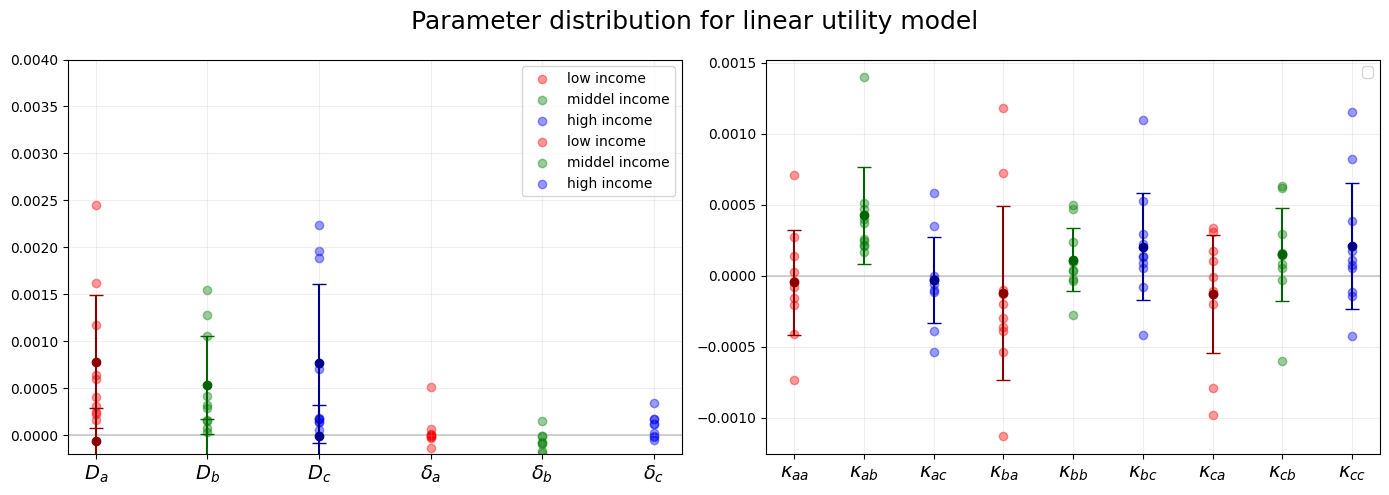

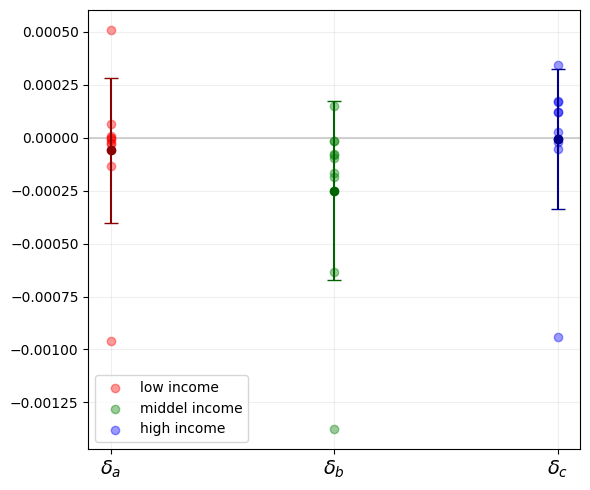

In [38]:
# One figure with two stacked subplots:
# Top: D, kappa, gamma parameters
# Bottom: all nu parameters
# Both share the same y-axis

fig = plt.figure(figsize=(14,5))

# 1 rows, 2 columns
gs = fig.add_gridspec(1, 2)

# Top row
ax1 = fig.add_subplot(gs[0, 0])   # top-left
ax2 = fig.add_subplot(gs[0, 1])   # top-right

fig.suptitle(
    "Parameter distribution for linear utility model",
    size=title_size + 2
)

# ============================================================
# TOP SUBPLOT : D, kappa, gamma
# ============================================================

top_ax = ax1
top_ax.axhline(0, color='lightgray', zorder=0)

# ---- Labels on x-axis ----
top_labels = [
    r'$D_a$', r'$D_b$', r'$D_c$',
    r'$\delta_a$', r'$\delta_b$', r'$\delta_c$'
]

xpos_top = np.arange(len(top_labels))

# ---- Diffusion coefficients D ----
for i in range(ns):

    params = grouped_MH1[i][0]

    mean = np.mean(params)
    std = np.std(params)

    x = np.full(len(params), xpos_top[i])

    top_ax.scatter(
        x,
        params,
        marker='o',
        alpha=0.4,
        color=species_colors[i],
        label=species[i]
    )

    top_ax.errorbar(
        xpos_top[i],
        mean,
        yerr=std,
        fmt='o',
        color=bar_colors[i],
        capsize=5
    )

for i in range(ns):

    params = grouped_MH1[i][11]

    mean = np.mean(params)
    std = np.std(params)

    x = np.full(len(params), xpos_top[i+3])

    top_ax.scatter(
        x,
        params,
        marker='o',
        alpha=0.4,
        color=species_colors[i],
        label=species[i]
    )

    top_ax.errorbar(
        xpos_top[i],
        mean,
        yerr=std,
        fmt='o',
        color=bar_colors[i],
        capsize=5
    )

ax1.set_ylim(-0.0002, 0.004)

ax1.set_xticks(xpos_top)
ax1.set_xticklabels(top_labels, fontsize=ax_size)
# ax[0].set_title(r"$D$ and $\Gamma$ parameters", size=title_size)
ax1.legend()

# ---- Kappa coefficients ----
# grouped_M3[sp][i+1]

top_ax = ax2
top_ax.axhline(0, color='lightgray', zorder=0)

kappa_labels = [
    r'$\kappa_{aa}$', r'$\kappa_{ab}$', r'$\kappa_{ac}$',
    r'$\kappa_{ba}$', r'$\kappa_{bb}$', r'$\kappa_{bc}$',
    r'$\kappa_{ca}$', r'$\kappa_{cb}$', r'$\kappa_{cc}$'
]

xpos_kappa = np.arange(len(kappa_labels))

inx = 0
for sp in range(ns):

    for i in range(ns):

        params = grouped_MH1[sp][i+1]

        mean = np.mean(params)
        std = np.std(params)

        x = np.full(len(params), xpos_kappa[inx])

        top_ax.scatter(
            x,
            params,
            marker='o',
            alpha=0.4,
            color=species_colors[i]
        )

        top_ax.errorbar(
            xpos_kappa[inx],
            mean,
            yerr=std,
            fmt='o',
            color=bar_colors[i],
            capsize=5
        )
        inx += 1

# ax2.set_ylim(-2e-6, 5e-6)

ax2.set_xticks(xpos_kappa)
ax2.set_xticklabels(kappa_labels, fontsize=ax_size)
# ax[1].set_title("κ parameters", size=title_size)
ax2.legend()
# ax2.set_ylim(-0.0002, 0.0004)

ax = [ax1, ax2]

for a in ax:
    a.grid(alpha=0.2)

# ax[1].set_ylabel("Parameter value", size=ax_size)

plt.tight_layout()
plt.show()


## Second plot: zoom in on delta

fig, ax = plt.subplots(figsize=(6, 5))

ax.axhline(0, color='lightgray', zorder=0)

# ---- Labels on x-axis ----
top_labels = [
    r'$\delta_a$', r'$\delta_b$', r'$\delta_c$'
]

xpos_top = np.arange(len(top_labels))

for i in range(ns):

    params = grouped_MH1[i][11]

    mean = np.mean(params)
    std = np.std(params)

    x = np.full(len(params), xpos_top[i])

    ax.scatter(
        x,
        params,
        marker='o',
        alpha=0.4,
        color=species_colors[i],
        label=species[i]
    )

    ax.errorbar(
        xpos_top[i],
        mean,
        yerr=std,
        fmt='o',
        color=bar_colors[i],
        capsize=5
    )

# ax1.set_ylim(-0.0002, 0.004)

ax.set_xticks(xpos_top)
ax.set_xticklabels(top_labels, fontsize=ax_size)
# ax[0].set_title(r"$D$ and $\Gamma$ parameters", size=title_size)
ax.legend()

ax.grid(alpha=0.2)

# ax[1].set_ylabel("Parameter value", size=ax_size)

plt.tight_layout()
plt.show()

## Performance

In [ ]:
N = (n-1, n-1)
L = (50,50)
Lx, Ly = L
sim_2d_fitted = fhd.fhd_2d_3species(L,N, bc= 'Neumann', fft=False)

noise = 0
frames = 1

ns = sim_2d_fitted.nspecies

Deltats = [1,2,3,4]

phi_MH1 = []


for i, Dt in enumerate(Deltats):
    for yr in range(1,6-Dt):
        scaled_theta = [Thetas_MH1[Dt][start_years[yr]][a] * scales[start_years[yr]][a] for a in range(ns)]
        D_fit, kappa_fit, nu_fit, Gamma_fit = fhd.unpack_theta(scaled_theta, ns, include_nu=False, include_Gamma=True, include_H=False)

        Gamma_fit_m = np.diag(Gamma_fit)

        param_fitted = {
            'D': D_fit / Dt,
            'kappa': kappa_fit / Dt,
            'Gamma': Gamma_fit_m / Dt,
        }

        # params_M1[i][yr].append(param_fitted)
        time_step = Dt 
        dt = 1
        nsteps = int(time_step / dt)

        st = time.time()
        phi_run = sim_2d_fitted.run(mirror[yr], param_fitted, nsteps, dt, noise, frames, model = "Vitelli", verbatum = False)
        et = time.time()
        # print(f"Simulation ran in t = {et-st:.6f} seconds")

        phi_masked = phi_run.copy()
        phi_masked[:,-1][masks[yr+Dt]] = 0.0
        # print(len(phi_M1), Dt, yr)

        phi_MH1.append(phi_masked[:,-1])


In [40]:
n_years = 5
mse_MH1_y1t = np.zeros((n_years-1,ns))
mse_MH1_y2t = np.zeros((n_years-2,ns))
mse_MH1_y3t = np.zeros((n_years-3,ns))
mse_MH1_y4t = np.zeros((n_years-4,ns))

for i, year in enumerate(range(2017, 2021)):
    data_year = eval(f"data_{year}")
    mse_MH1_y1t[i] =  [np.mean((phi_MH1[i][sp,:] - data_year[sp,:])**2) / bases[i+1][sp] for sp in range(ns)]

for i, year in enumerate(range(2018, 2021)):
    data_year = eval(f"data_{year}")
    mse_MH1_y2t[i] = [np.mean((phi_MH1[i+4][sp,:] - data_year[sp,:])**2) / bases_2y[i+1][sp] for sp in range(ns)]
    
for i, year in enumerate(range(2019, 2021)):
    data_year = eval(f"data_{year}")
    mse_MH1_y3t[i] = [np.mean((phi_MH1[i+7][sp,:] - data_year[sp,:])**2) / bases_3y[i+1][sp] for sp in range(ns)]

for i, year in enumerate(range(2020, 2021)):
    data_year = eval(f"data_{year}")
    mse_MH1_y4t[i] = [np.mean((phi_MH1[i+9][sp,:] - data_year[sp,:])**2) / bases_4y[i+1][sp] for sp in range(ns)]


# Model H2 (eco + quad ut)

## Thetas

In [41]:
Deltas = [1, 2, 3, 4]
Thetas_MH2 = defaultdict(dict)

for D_t in Deltas:
    for i in range(1, 6-D_t):
        Thetas = fhd.compute_thetas(
        [As[start_years[i]][a] for a in range(ns)],  
        mirror[i],
        mirror[i+D_t],
        masks[i],   # Mask from earliest year
        dx, dy,
        ns,
        delta_t = D_t,
        include_nu = True,
        include_Gamma= True,
        include_H = True,
    )
        Thetas_MH2[D_t][start_years[i]] = Thetas

In [42]:
thetas_all = {
    1: np.array([Thetas_MH2[1][year] for year in eco_start_years]),
    2: np.array([Thetas_MH2[2][year] for year in eco_start_years[:-1]]),
    3: np.array([Thetas_MH2[3][year] for year in eco_start_years[:-2]]),
    4: np.array([Thetas_MH2[4][year] for year in eco_start_years[:-3]]),
}

ns = 3
n_params = 12

grouped_MH2 = {
    species: {
        param: np.concatenate([
            theta[:, species, param] / timestep
            for timestep, theta in thetas_all.items()
        ])
        for param in range(n_params)
    }
    for species in range(ns)
}

C:\Users\rmosk\AppData\Local\Temp\ipykernel_30240\4080418933.py:181: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(fontsize=ax_size)


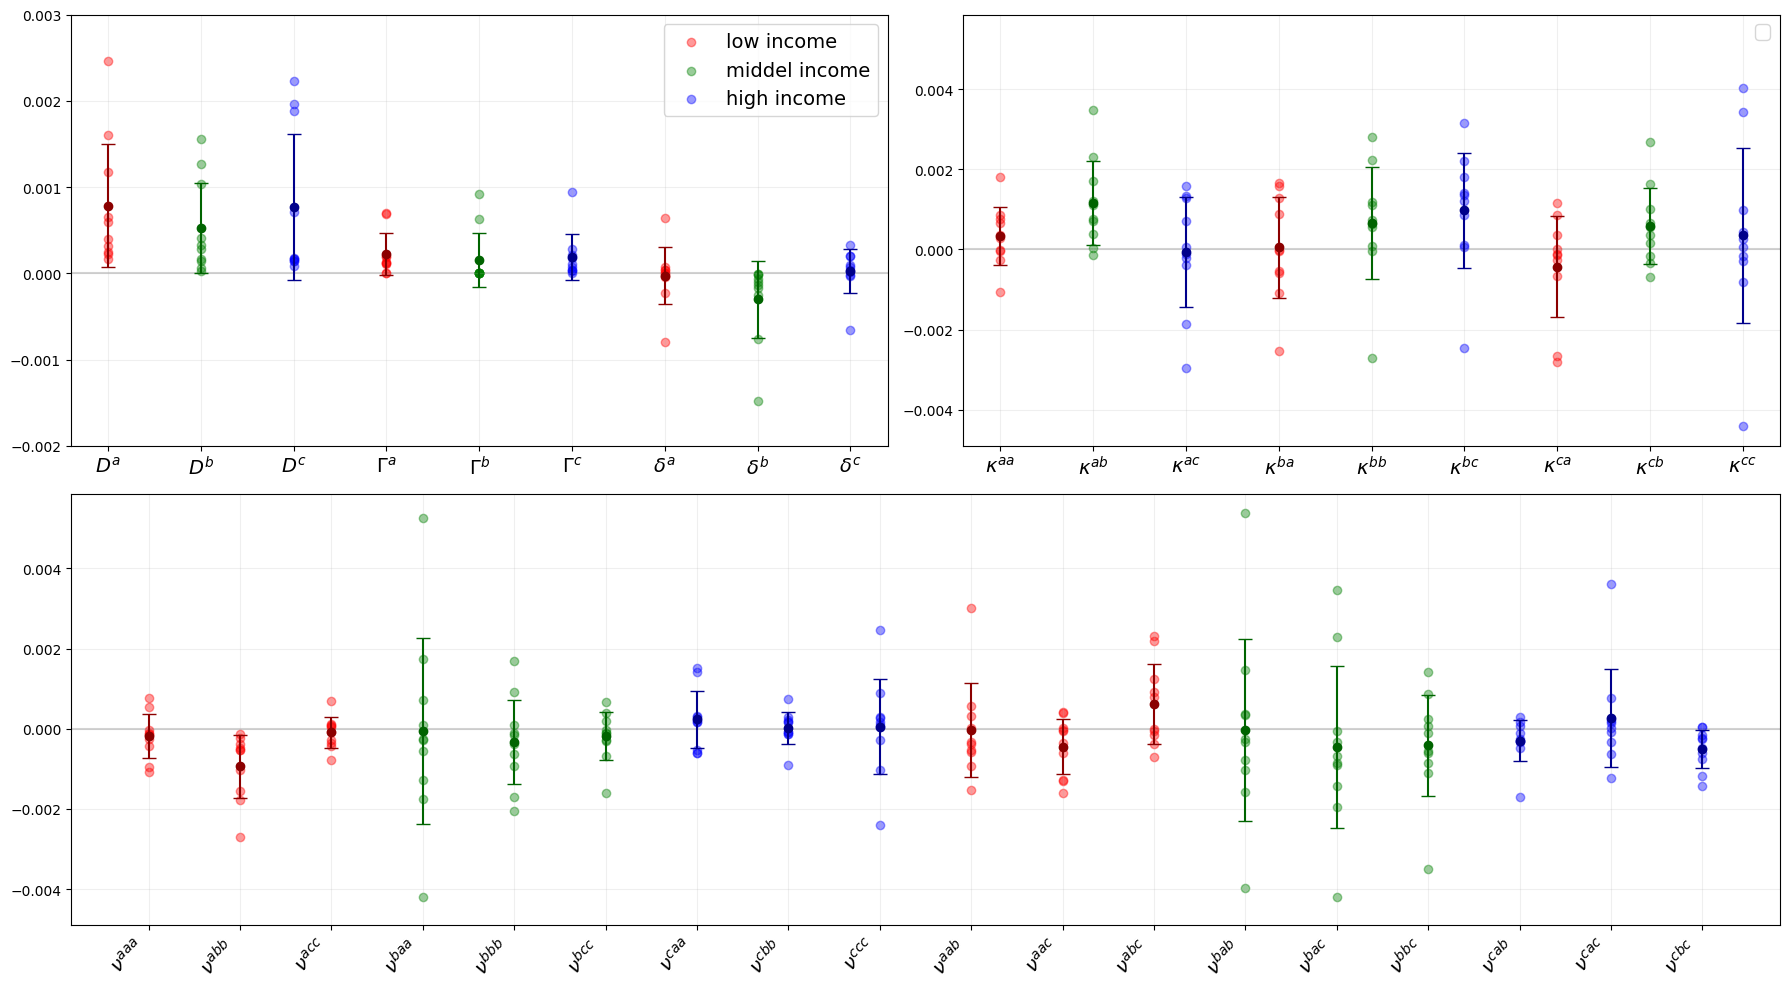

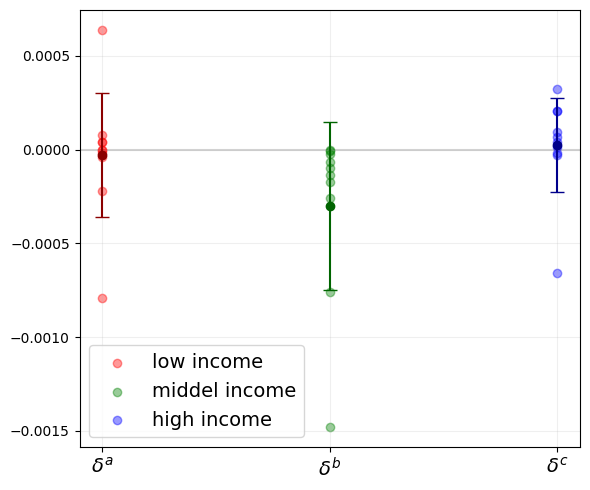

In [43]:
# One figure with two stacked subplots:
# Top: D, kappa, gamma parameters
# Bottom: all nu parameters
# Both share the same y-axis

fig = plt.figure(figsize=(18,10))

# 2 rows, 2 columns
gs = fig.add_gridspec(2, 2)

# Top row
ax1 = fig.add_subplot(gs[0, 0])   # top-left
ax2 = fig.add_subplot(gs[0, 1])   # top-right

# Bottom row spans BOTH columns
ax3 = fig.add_subplot(gs[1, :], sharey = ax2)

ax = [ax1, ax2, ax3]

# fig.suptitle(
#     "Parameter distribution for housing utility model",
#     size=title_size + 2
# )

# ============================================================
# TOP SUBPLOT : D, kappa, gamma
# ============================================================

top_ax = ax[0]
top_ax.axhline(0, color='lightgray', zorder=0)

# ---- Labels on x-axis ----
top_labels = [
    r'$D^a$', r'$D^b$', r'$D^c$',
    r'$\Gamma^a$', r'$\Gamma^b$', r'$\Gamma^c$',
    r'$\delta^a$', r'$\delta^b$', r'$\delta^c$'
]

xpos_top = np.arange(len(top_labels))

# ---- Diffusion coefficients D ----
for i in range(ns):

    params = grouped_MH2[i][0]

    mean = np.mean(params)
    std = np.std(params)

    x = np.full(len(params), xpos_top[i])

    top_ax.scatter(
        x,
        params,
        marker='o',
        alpha=0.4,
        color=species_colors[i],
        label=species[i]
    )

    top_ax.errorbar(
        xpos_top[i],
        mean,
        yerr=std,
        fmt='o',
        color=bar_colors[i],
        capsize=5
    )

# ---- Gamma coefficients ----
for i in range(ns):

    params = grouped_MH2[i][10]

    mean = np.mean(params)
    std = np.std(params)

    x_index = 3 + i
    x = np.full(len(params), xpos_top[x_index])

    top_ax.scatter(
        x,
        params,
        marker='o',
        alpha=0.4,
        color=species_colors[i]
    )

    top_ax.errorbar(
        xpos_top[x_index],
        mean,
        yerr=std,
        fmt='o',
        color=bar_colors[i],
        capsize=5
    )

# ---- delta coefficients ----
for i in range(ns):

    params = grouped_MH2[i][11]

    mean = np.mean(params)
    std = np.std(params)

    x_index = 6 + i
    x = np.full(len(params), xpos_top[x_index])

    top_ax.scatter(
        x,
        params,
        marker='o',
        alpha=0.4,
        color=species_colors[i]
    )

    top_ax.errorbar(
        xpos_top[x_index],
        mean,
        yerr=std,
        fmt='o',
        color=bar_colors[i],
        capsize=5
    )

ax[0].set_xticks(xpos_top)
ax[0].set_xticklabels(top_labels, fontsize=ax_size)
# ax[0].set_title(r"$D$ and $\Gamma$ parameters", size=title_size)
ax[0].legend(fontsize=ax_size)

ax[0].set_ylim(-0.002, 0.003)
# ax[0].set_ylim(-0.0002, 0.004)

# ---- Kappa coefficients ----
# grouped_M3[sp][i+1]

top_ax = ax[1]
top_ax.axhline(0, color='lightgray', zorder=0)

kappa_labels = [
    r'$\kappa^{aa}$', r'$\kappa^{ab}$', r'$\kappa^{ac}$',
    r'$\kappa^{ba}$', r'$\kappa^{bb}$', r'$\kappa^{bc}$',
    r'$\kappa^{ca}$', r'$\kappa^{cb}$', r'$\kappa^{cc}$'
]

xpos_kappa = np.arange(len(kappa_labels))

inx = 0
for sp in range(ns):

    for i in range(ns):

        params = grouped_MH2[sp][i+1]

        mean = np.mean(params)
        std = np.std(params)

        x = np.full(len(params), xpos_kappa[inx])

        top_ax.scatter(
            x,
            params,
            marker='o',
            alpha=0.4,
            color=species_colors[i]
        )

        top_ax.errorbar(
            xpos_kappa[inx],
            mean,
            yerr=std,
            fmt='o',
            color=bar_colors[i],
            capsize=5
        )
        inx += 1


ax[1].set_xticks(xpos_kappa)
ax[1].set_xticklabels(kappa_labels, fontsize=ax_size)
# ax[1].set_title("κ parameters", size=title_size)
ax[1].legend(fontsize=ax_size)

# ax[1].set_ylim(-0.0002, 0.0003)

# ============================================================
# BOTTOM SUBPLOT : all nu parameters
# ============================================================

bottom_ax = ax[2]
bottom_ax.axhline(0, color='lightgray', zorder=0)

nu_labels = [
    r'$\nu^{aaa}$', r'$\nu^{abb}$', r'$\nu^{acc}$',
    r'$\nu^{baa}$', r'$\nu^{bbb}$', r'$\nu^{bcc}$',
    r'$\nu^{caa}$', r'$\nu^{cbb}$', r'$\nu^{ccc}$',
    r'$\nu^{aab}$', r'$\nu^{aac}$', r'$\nu^{abc}$',
    r'$\nu^{bab}$', r'$\nu^{bac}$', r'$\nu^{bbc}$',
    r'$\nu^{cab}$', r'$\nu^{cac}$', r'$\nu^{cbc}$'
]

xpos_bottom = np.arange(len(nu_labels))

# First 9 nu terms
nu_index = 0

for sp in range(ns):

    for i in range(ns):

        params = grouped_MH2[sp][i+4]

        mean = np.mean(params)
        std = np.std(params)

        x = np.full(len(params), xpos_bottom[nu_index])

        bottom_ax.scatter(
            x,
            params,
            marker='o',
            alpha=0.4,
            color=species_colors[sp]
        )

        bottom_ax.errorbar(
            xpos_bottom[nu_index],
            mean,
            yerr=std,
            fmt='o',
            color=bar_colors[sp],
            capsize=5
        )

        nu_index += 1

# Second 9 nu terms
nu_index = 9

for sp in range(ns):

    for i in range(ns):

        params = grouped_MH2[sp][i+7]

        mean = np.mean(params)
        std = np.std(params)

        x = np.full(len(params), xpos_bottom[nu_index])

        bottom_ax.scatter(
            x,
            params,
            marker='o',
            alpha=0.4,
            color=species_colors[sp]
        )

        bottom_ax.errorbar(
            xpos_bottom[nu_index],
            mean,
            yerr=std,
            fmt='o',
            color=bar_colors[sp],
            capsize=5
        )

        nu_index += 1

bottom_ax.set_xticks(xpos_bottom)
bottom_ax.set_xticklabels(
    nu_labels,
    rotation=45,
    ha='right',
    fontsize=ax_size
)

# bottom_ax.set_ylim(-9e-5, 7e-5)

# bottom_ax.set_title(r'$\nu$ coefficients', size=title_size)

# ============================================================
# Shared formatting
# ============================================================

for a in ax:
    a.grid(alpha=0.2)

# ax[1].set_ylabel("Parameter value", size=ax_size)

plt.tight_layout()
plt.show()


## Second plot: zoom in on delta

fig, ax = plt.subplots(figsize=(6, 5))

ax.axhline(0, color='lightgray', zorder=0)

# ---- Labels on x-axis ----
top_labels = [
    r'$\delta^a$', r'$\delta^b$', r'$\delta^c$'
]

xpos_top = np.arange(len(top_labels))

for i in range(ns):

    params = grouped_MH2[i][11]

    mean = np.mean(params)
    std = np.std(params)

    x = np.full(len(params), xpos_top[i])

    ax.scatter(
        x,
        params,
        marker='o',
        alpha=0.4,
        color=species_colors[i],
        label=species[i]
    )

    ax.errorbar(
        xpos_top[i],
        mean,
        yerr=std,
        fmt='o',
        color=bar_colors[i],
        capsize=5
    )

# ax1.set_ylim(-0.0002, 0.004)

ax.set_xticks(xpos_top)
ax.set_xticklabels(top_labels, fontsize=ax_size)
# ax[0].set_title(r"$D$ and $\Gamma$ parameters", size=title_size)
ax.legend(fontsize=ax_size)
# ax.set_ylim(-0.0001, 0.0002)

ax.grid(alpha=0.2)

# ax[1].set_ylabel("Parameter value", size=ax_size)

plt.tight_layout()
plt.show()


C:\Users\rmosk\AppData\Local\Temp\ipykernel_30240\3611887229.py:182: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(fontsize=ax_size)


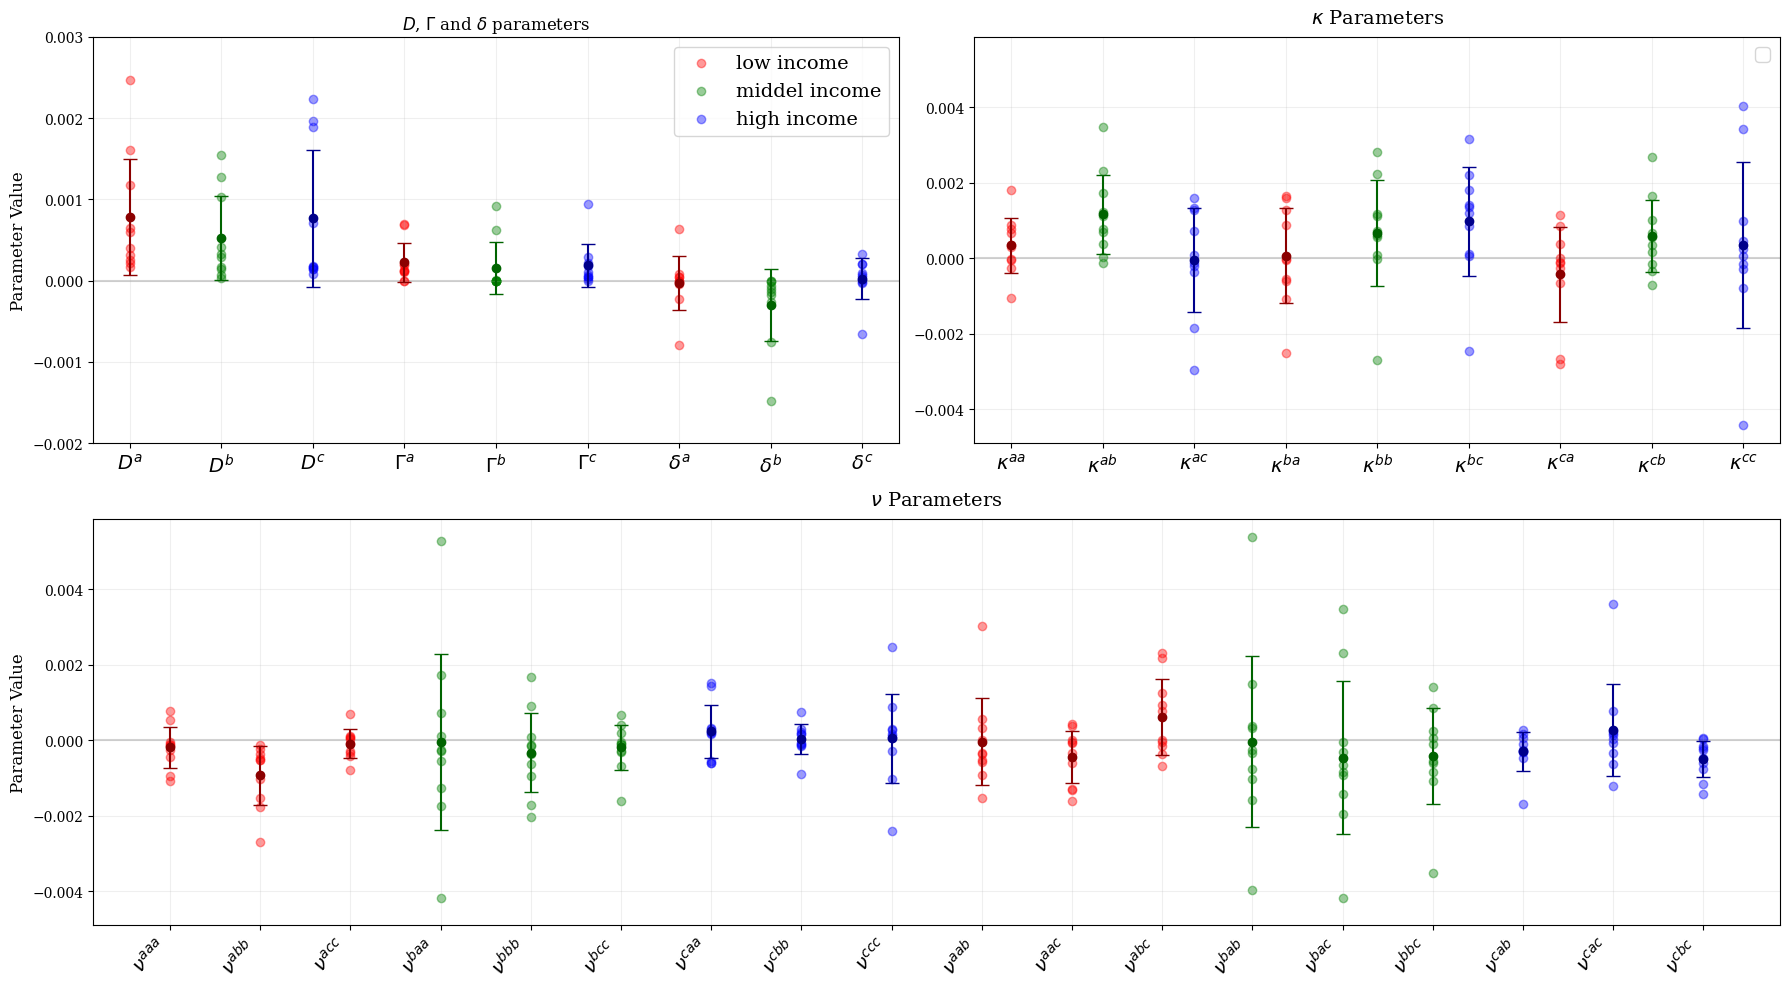

: 

In [ ]:
# One figure with two stacked subplots:
# Top: D, kappa, gamma parameters
# Bottom: all nu parameters
# Both share the same y-axis

fig = plt.figure(figsize=(18,10))

# 2 rows, 2 columns
gs = fig.add_gridspec(2, 2)

# Top row
ax1 = fig.add_subplot(gs[0, 0])   # top-left
ax2 = fig.add_subplot(gs[0, 1])   # top-right

# Bottom row spans BOTH columns
ax3 = fig.add_subplot(gs[1, :], sharey = ax2)

ax = [ax1, ax2, ax3]

# fig.suptitle(
#     "Parameter distribution for housing utility model",
#     size=title_size + 2
# )

# ============================================================
# TOP SUBPLOT : D, kappa, gamma
# ============================================================

top_ax = ax[0]
top_ax.axhline(0, color='lightgray', zorder=0)

# ---- Labels on x-axis ----
top_labels = [
    r'$D^a$', r'$D^b$', r'$D^c$',
    r'$\Gamma^a$', r'$\Gamma^b$', r'$\Gamma^c$',
    r'$\delta^a$', r'$\delta^b$', r'$\delta^c$'
]

xpos_top = np.arange(len(top_labels))

# ---- Diffusion coefficients D ----
for i in range(ns):

    params = grouped_MH2[i][0]

    mean = np.mean(params)
    std = np.std(params)

    x = np.full(len(params), xpos_top[i])

    top_ax.scatter(
        x,
        params,
        marker='o',
        alpha=0.4,
        color=species_colors[i],
        label=species[i]
    )

    top_ax.errorbar(
        xpos_top[i],
        mean,
        yerr=std,
        fmt='o',
        color=bar_colors[i],
        capsize=5
    )

# ---- Gamma coefficients ----
for i in range(ns):

    params = grouped_MH2[i][10]

    mean = np.mean(params)
    std = np.std(params)

    x_index = 3 + i
    x = np.full(len(params), xpos_top[x_index])

    top_ax.scatter(
        x,
        params,
        marker='o',
        alpha=0.4,
        color=species_colors[i]
    )

    top_ax.errorbar(
        xpos_top[x_index],
        mean,
        yerr=std,
        fmt='o',
        color=bar_colors[i],
        capsize=5
    )

# ---- delta coefficients ----
for i in range(ns):

    params = grouped_MH2[i][11]

    mean = np.mean(params)
    std = np.std(params)

    x_index = 6 + i
    x = np.full(len(params), xpos_top[x_index])

    top_ax.scatter(
        x,
        params,
        marker='o',
        alpha=0.4,
        color=species_colors[i]
    )

    top_ax.errorbar(
        xpos_top[x_index],
        mean,
        yerr=std,
        fmt='o',
        color=bar_colors[i],
        capsize=5
    )

ax[0].set_xticks(xpos_top)
ax[0].set_xticklabels(top_labels, fontsize=ax_size)
ax[0].set_title(r"$D$, $\Gamma$ and $\delta$ parameters", size=12)
ax[0].set_ylabel("Parameter Value", fontsize=12)
ax[0].legend(fontsize=ax_size)

ax[0].set_ylim(-0.002, 0.003)
# ax[0].set_ylim(-0.0002, 0.004)

# ---- Kappa coefficients ----
# grouped_M3[sp][i+1]

top_ax = ax[1]
top_ax.axhline(0, color='lightgray', zorder=0)

kappa_labels = [
    r'$\kappa^{aa}$', r'$\kappa^{ab}$', r'$\kappa^{ac}$',
    r'$\kappa^{ba}$', r'$\kappa^{bb}$', r'$\kappa^{bc}$',
    r'$\kappa^{ca}$', r'$\kappa^{cb}$', r'$\kappa^{cc}$'
]

xpos_kappa = np.arange(len(kappa_labels))

inx = 0
for sp in range(ns):

    for i in range(ns):

        params = grouped_MH2[sp][i+1]

        mean = np.mean(params)
        std = np.std(params)

        x = np.full(len(params), xpos_kappa[inx])

        top_ax.scatter(
            x,
            params,
            marker='o',
            alpha=0.4,
            color=species_colors[i]
        )

        top_ax.errorbar(
            xpos_kappa[inx],
            mean,
            yerr=std,
            fmt='o',
            color=bar_colors[i],
            capsize=5
        )
        inx += 1


ax[1].set_xticks(xpos_kappa)
ax[1].set_xticklabels(kappa_labels, fontsize=ax_size)
# ax[1].set_title("κ parameters", size=title_size)
ax[1].legend(fontsize=ax_size)
# ax[1].set_ylabel("Parameter Value", fontsize=12)
ax[1].set_title(r"$\kappa$ Parameters", fontsize=14, pad=10)

# ax[1].set_ylim(-0.0002, 0.0003)

# ============================================================
# BOTTOM SUBPLOT : all nu parameters
# ============================================================

bottom_ax = ax[2]
bottom_ax.axhline(0, color='lightgray', zorder=0)

nu_labels = [
    r'$\nu^{aaa}$', r'$\nu^{abb}$', r'$\nu^{acc}$',
    r'$\nu^{baa}$', r'$\nu^{bbb}$', r'$\nu^{bcc}$',
    r'$\nu^{caa}$', r'$\nu^{cbb}$', r'$\nu^{ccc}$',
    r'$\nu^{aab}$', r'$\nu^{aac}$', r'$\nu^{abc}$',
    r'$\nu^{bab}$', r'$\nu^{bac}$', r'$\nu^{bbc}$',
    r'$\nu^{cab}$', r'$\nu^{cac}$', r'$\nu^{cbc}$'
]

xpos_bottom = np.arange(len(nu_labels))

# First 9 nu terms
nu_index = 0

for sp in range(ns):

    for i in range(ns):

        params = grouped_MH2[sp][i+4]

        mean = np.mean(params)
        std = np.std(params)

        x = np.full(len(params), xpos_bottom[nu_index])

        bottom_ax.scatter(
            x,
            params,
            marker='o',
            alpha=0.4,
            color=species_colors[sp]
        )

        bottom_ax.errorbar(
            xpos_bottom[nu_index],
            mean,
            yerr=std,
            fmt='o',
            color=bar_colors[sp],
            capsize=5
        )

        nu_index += 1

# Second 9 nu terms
nu_index = 9

for sp in range(ns):

    for i in range(ns):

        params = grouped_MH2[sp][i+7]

        mean = np.mean(params)
        std = np.std(params)

        x = np.full(len(params), xpos_bottom[nu_index])

        bottom_ax.scatter(
            x,
            params,
            marker='o',
            alpha=0.4,
            color=species_colors[sp]
        )

        bottom_ax.errorbar(
            xpos_bottom[nu_index],
            mean,
            yerr=std,
            fmt='o',
            color=bar_colors[sp],
            capsize=5
        )

        nu_index += 1

bottom_ax.set_xticks(xpos_bottom)
bottom_ax.set_xticklabels(
    nu_labels,
    rotation=45,
    ha='right',
    fontsize=ax_size
)

# bottom_ax.set_xticks(xpos_bottom)
# bottom_ax.set_xticklabels(nu_labels, rotation=45, ha='right', fontsize=12)
bottom_ax.set_ylabel("Parameter Value", fontsize=12)
bottom_ax.set_title(r"$\nu$ Parameters", fontsize=14, pad=10)

# bottom_ax.set_ylim(-9e-5, 7e-5)

# bottom_ax.set_title(r'$\nu$ coefficients', size=title_size)

# ============================================================
# Shared formatting
# ============================================================

for a in ax:
    a.grid(alpha=0.2)

# ax[1].set_ylabel("Parameter value", size=ax_size)

plt.tight_layout()
plt.show()



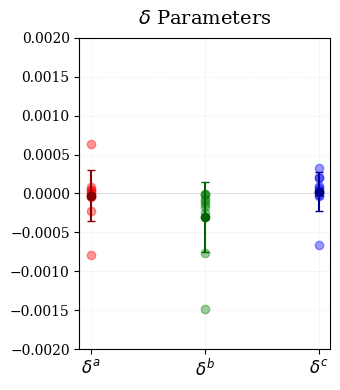

In [76]:
# Set global font properties (same as main plot)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Create figure
fig, ax = plt.subplots(figsize=(3.5, 4))

# Add zero line
ax.axhline(0, color='lightgray', zorder=0, linewidth=0.5)

# Labels on x-axis
delta_labels = [r'$\delta^a$', r'$\delta^b$', r'$\delta^c$']
xpos_delta = np.arange(len(delta_labels))

# Plot delta parameters
for i in range(ns):
    params = grouped_MH2[i][11]
    mean = np.mean(params)
    std = np.std(params)
    x = np.full(len(params), xpos_delta[i])

    ax.scatter(
        x,
        params,
        marker='o',
        alpha=0.4,
        color=species_colors[i],
        label=species[i]
    )

    ax.errorbar(
        xpos_delta[i],
        mean,
        yerr=std,
        fmt='o',
        color=bar_colors[i],
        capsize=3
    )

# Set x-ticks and labels
ax.set_xticks(xpos_delta)
ax.set_xticklabels(delta_labels, fontsize=12)

# Set y-label
# ax.set_ylabel("Parameter Value", fontsize=12)

# Add title
ax.set_title(r"$\delta$ Parameters", fontsize=14, pad=10)  # Added subtitle

# Add legend
# ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.05), fontsize=12)

# Set y-axis limits
ax.set_ylim(-0.002, 0.002)

# Add grid
ax.grid(alpha=0.2, linestyle='--', linewidth=0.5)

# Adjust layout
plt.tight_layout()
plt.show()

## Performance

In [44]:
N = (n-1, n-1)
L = (50,50)
Lx, Ly = L
sim_2d_fitted = fhd.fhd_2d_3species(L,N, bc= 'Neumann', fft=False)

noise = 0
frames = 1

ns = sim_2d_fitted.nspecies

Deltats = [1,2,3,4]

phi_MH2 = []

for i, Dt in enumerate(Deltats):
    for yr in range(1,6-Dt):
        scaled_theta = [Thetas_MH2[Dt][start_years[yr]][a] * scales[start_years[yr]][a] for a in range(ns)]
        D_fit, kappa_fit, nu_fit, Gamma_fit = fhd.unpack_theta(scaled_theta, ns, include_nu=False, include_Gamma=True, include_H=False)

        Gamma_fit_m = np.diag(Gamma_fit)

        param_fitted = {
            'D': D_fit / Dt,
            'kappa': kappa_fit / Dt,
            'Gamma': Gamma_fit_m / Dt,
        }

        # params_M1[i][yr].append(param_fitted)
        time_step = Dt 
        dt = 1
        nsteps = int(time_step / dt)

        st = time.time()
        phi_run = sim_2d_fitted.run(mirror[yr], param_fitted, nsteps, dt, noise, frames, model = "Vitelli", verbatum = False)
        et = time.time()
        # print(f"Simulation ran in t = {et-st:.6f} seconds")

        phi_masked = phi_run.copy()
        phi_masked[:,-1][masks[yr+Dt]] = 0.0
        # print(len(phi_M1), Dt, yr)

        phi_MH2.append(phi_masked[:,-1])


In [45]:
n_years = 5
mse_MH2_y1t = np.zeros((n_years-1,ns))
mse_MH2_y2t = np.zeros((n_years-2,ns))
mse_MH2_y3t = np.zeros((n_years-3,ns))
mse_MH2_y4t = np.zeros((n_years-4,ns))

for i, year in enumerate(range(2017, 2021)):
    data_year = eval(f"data_{year}")
    mse_MH2_y1t[i] =  [np.mean((phi_MH2[i][sp,:] - data_year[sp,:])**2) / bases[i+1][sp] for sp in range(ns)]

for i, year in enumerate(range(2018, 2021)):
    data_year = eval(f"data_{year}")
    mse_MH2_y2t[i] = [np.mean((phi_MH2[i+4][sp,:] - data_year[sp,:])**2) / bases_2y[i+1][sp] for sp in range(ns)]
    
for i, year in enumerate(range(2019, 2021)):
    data_year = eval(f"data_{year}")
    mse_MH2_y3t[i] = [np.mean((phi_MH2[i+7][sp,:] - data_year[sp,:])**2) / bases_3y[i+1][sp] for sp in range(ns)]

for i, year in enumerate(range(2020, 2021)):
    data_year = eval(f"data_{year}")
    mse_MH2_y4t[i] = [np.mean((phi_MH2[i+9][sp,:] - data_year[sp,:])**2) / bases_4y[i+1][sp] for sp in range(ns)]


# Performance all

In [77]:
mean_M1_y1t = np.mean(mse_M1_y1t, axis=0)
mean_M1_y2t = np.mean(mse_M1_y2t, axis=0)
mean_M1_y3t = np.mean(mse_M1_y3t, axis=0)
mean_M1_y4t = np.mean(mse_M1_y4t, axis=0)
mean_M1_y5t = np.mean(mse_M1_y5t, axis=0)

mean_M2_y1t = np.mean(mse_M2_y1t, axis=0)
mean_M2_y2t = np.mean(mse_M2_y2t, axis=0)
mean_M2_y3t = np.mean(mse_M2_y3t, axis=0)
mean_M2_y4t = np.mean(mse_M2_y4t, axis=0)
mean_M2_y5t = np.mean(mse_M2_y5t, axis=0)

mean_MH0_y1t = np.mean(mse_MH0_y1t, axis=0)
mean_MH0_y2t = np.mean(mse_MH0_y2t, axis=0)
mean_MH0_y3t = np.mean(mse_MH0_y3t, axis=0)
mean_MH0_y4t = np.mean(mse_MH0_y4t, axis=0)

mean_MH1_y1t = np.mean(mse_MH1_y1t, axis=0)
mean_MH1_y2t = np.mean(mse_MH1_y2t, axis=0)
mean_MH1_y3t = np.mean(mse_MH1_y3t, axis=0)
mean_MH1_y4t = np.mean(mse_MH1_y4t, axis=0)

mean_MH2_y1t = np.mean(mse_MH2_y1t, axis=0)
mean_MH2_y2t = np.mean(mse_MH2_y2t, axis=0)
mean_MH2_y3t = np.mean(mse_MH2_y3t, axis=0)
mean_MH2_y4t = np.mean(mse_MH2_y4t, axis=0)

mean_M1_all = np.mean([mean_M1_y1t, mean_M1_y2t, mean_M1_y3t, mean_M1_y4t, mean_M1_y5t], axis=0)
mean_M2_all = np.mean([mean_M2_y1t, mean_M2_y2t, mean_M2_y3t, mean_M2_y4t, mean_M2_y5t], axis=0)
mean_MH0_all = np.mean([mean_MH0_y1t, mean_MH0_y2t, mean_MH0_y3t, mean_MH0_y4t], axis=0)
mean_MH1_all = np.mean([mean_MH1_y1t, mean_MH1_y2t, mean_MH1_y3t, mean_MH1_y4t], axis=0)
mean_MH2_all = np.mean([mean_MH2_y1t, mean_MH2_y2t, mean_MH2_y3t, mean_MH2_y4t], axis=0)


mean_zero = np.ones_like(mean_M1_y1t)

model_means = {
    "Zero": np.array([mean_zero, mean_zero, mean_zero, mean_zero, mean_zero]),
    "Linear": np.array([mean_M1_y1t, mean_M1_y2t, mean_M1_y3t, mean_M1_y4t, mean_M1_y5t]),
    "Quadratic": np.array([mean_M2_y1t, mean_M2_y2t, mean_M2_y3t, mean_M2_y4t, mean_M2_y5t]),
    "Economic zero": np.array([mean_MH0_y1t, mean_MH0_y2t, mean_MH0_y3t, mean_MH0_y4t]),
    "Economic Linear": np.array([mean_MH1_y1t, mean_MH1_y2t, mean_MH1_y3t, mean_MH1_y4t]),
    "Economic Quadratic": np.array([mean_MH2_y1t, mean_MH2_y2t, mean_MH2_y3t, mean_MH2_y4t])
}

In [47]:
models = ["Zero", "Linear", "Quadratic", "Economic zero", "Economic Linear", "Economic Quadratic"]
# models = ["Zero", "Linear", "Quadratic","Economic zero"]
step_markers = ["o", "s", "^", "D", "v"]
step_titles = ["1 year", "2 years", "3 years", "4 years", "5 years"]


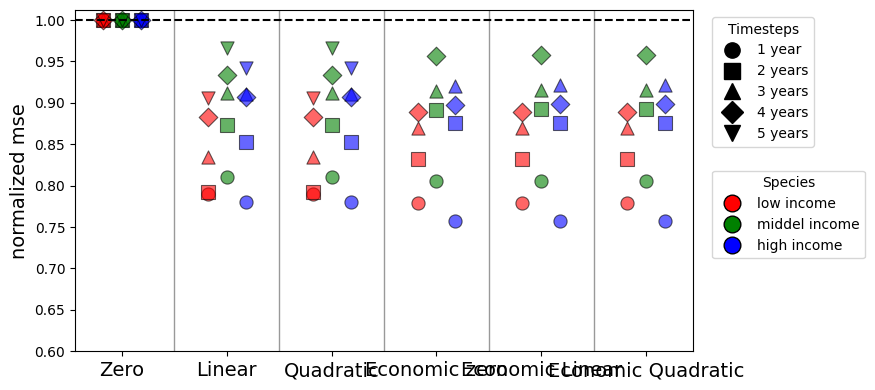

In [48]:
# Create figure
fig, ax = plt.subplots(figsize=(12, 4))

# X positions for each model
xpos = np.arange(len(models))

# Offsets to avoid overlapping points
offsets = np.linspace(-0.18, 0.18, len(species))

# Plot each model's data
for m_idx, model in enumerate(models):
    data = model_means[model]
    for t_idx in range(len(data)):
        for s_idx in range(len(species)):
            ax.scatter(
                xpos[m_idx] + offsets[s_idx],
                data[t_idx, s_idx],
                color=species_colors[s_idx],
                marker=step_markers[t_idx],
                s=90,
                edgecolor='black',
                linewidth=0.8,
                alpha=0.6,
            )

# Axis formatting
ax.set_xticks(xpos)
ax.set_xticklabels(models, fontsize=ax_size)
ax.set_ylabel("normalized mse", fontsize=ax_size)
ax.axhline(1, color='black', linestyle='--')
ax.set_ylim(0.6)

# Add vertical lines between models
vlines = [0.5 + i for i in range(len(models)-1)]
for x in vlines:
    ax.axvline(x, color='black', linewidth=1, alpha=0.4)

# Legends
# Species legend (colors)
species_handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=species_colors[i],
        markeredgecolor='black',
        markersize=ax_size-2,
        label=species[i],
        # fontsize=ax_size
    )
    for i in range(len(species))
]

# Timestep legend (markers)
timestep_handles = [
    plt.Line2D(
        [0], [0],
        marker=step_markers[i],
        color='black',
        linestyle='None',
        markersize=ax_size-3,
        label=step_titles[i],
        # fontsize=ax_size
    )
    for i in range(len(step_titles))
]

# Add legends
leg1 = ax.legend(
    handles=species_handles,
    title="Species",
    loc='upper left',
    bbox_to_anchor=(1.02, 0.55)
)
leg2 = ax.legend(
    handles=timestep_handles,
    title="Timesteps",
    loc='upper left',
    bbox_to_anchor=(1.02, 1)
)
ax.add_artist(leg1)

# Adjust layout
plt.tight_layout(rect=[0, 0, 0.7, 1])
plt.show()

In [78]:
print(mean_M1_all)
print(mean_M2_all)
print(mean_MH0_all)
print(mean_MH1_all)
print(mean_MH2_all)

[0.84123948 0.89933458 0.87880557]
[0.84121238 0.89941651 0.8788062 ]
[0.84275503 0.89187939 0.86254697]
[0.84273312 0.89271634 0.86312631]
[0.84272028 0.89279619 0.86311898]
